## Librerias

In [5]:
import pandas as pd
import statsmodels.api as sm

print("Entorno funcionando correctamente")
print(pd.__version__)


Entorno funcionando correctamente
1.5.3


In [1]:
import warnings
#import prince
#import textwrap

import numpy as np
import pandas as pd
import seaborn as sns
from os import listdir
from os.path import isfile, join
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')
from utils import decodificar_variables, wrap_labels
pd.options.display.float_format = '{:.4f}'.format
# Tutorial: https://www.geeksforgeeks.org/data-science-with-python-tutorial/
import prince







In [2]:
import numpy as np
import pandas as pd

print(pd.__version__)  # 1.5.3
print(np.__version__)  # 1.26.4


1.5.3
1.26.4


## Carga de Datos

In [3]:
# Definimos ruta de los archivos
ruta = 'datasets/'
primer_archivo = 'usu_individual_t117.txt'
# Cargamos el primer archivo
df_inicial = pd.read_csv(f'{ruta}{primer_archivo}', sep=';')
# Cargar los los nombres de los archivos en la lista 'archivos' link: https://es.stackoverflow.com/questions/24278/c%C3%B3mo-listar-todos-los-archivos-de-una-carpeta-usando-python
archivos = [arch for arch in listdir(ruta) if isfile(join(ruta, arch)) and arch not in primer_archivo]

In [4]:
for archivo in archivos:
    df_tmp = pd.read_csv(f'{ruta}{archivo}', sep=';')
    df_inicial = df_inicial.append(df_tmp)
    print(archivo)

Individual_t215.csv
usu_individual_t118.txt
usu_individual_t119.txt
usu_individual_T120.txt
usu_individual_T121.txt
usu_individual_T122.txt
usu_individual_T123.txt
usu_individual_T124.txt
usu_individual_T216.txt
usu_individual_t217.txt
usu_individual_t218.txt
usu_individual_t219.txt
usu_Individual_T220.txt
usu_individual_T221.txt
usu_individual_T222.txt
usu_individual_T223.txt
usu_individual_T224.txt
usu_individual_t316.txt
usu_individual_t317.txt
usu_individual_T318.txt
usu_individual_T319.txt
usu_individual_T320.txt
usu_individual_T321.txt
usu_individual_T322.txt
usu_individual_T323.txt
usu_individual_T324.txt
usu_individual_t416.txt
usu_Individual_T417.txt
usu_individual_t418.txt
usu_individual_T419.txt
usu_individual_T420.txt
usu_individual_T421.txt
usu_individual_T422.txt
usu_individual_T423.txt


In [12]:
df_inicial.shape

(1836404, 182)

In [7]:
df_inicial.head()

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,PONDIH,PP04B_CAES,PP11B_CAES,IDIMPP,Unnamed: 177
0,TQRMNOQURHKOMLCDEFIAH00469284,2017,1,1,4,1,43,S,2,861,...,,,,,,0.0000,NaN,NaN,NaN,NaN
1,TQRMNOQURHKOMLCDEFIAH00469284,2017,1,1,5,1,43,S,2,861,...,,,,,,0.0000,NaN,NaN,NaN,NaN
2,TQRMNOQURHKOMLCDEFIAH00469284,2017,1,1,6,1,43,S,2,861,...,,,,,,0.0000,NaN,NaN,NaN,NaN
3,TQRMNOQURHKOMLCDEFIAH00469284,2017,1,1,7,1,43,S,2,861,...,,,,,,0.0000,NaN,NaN,NaN,NaN
4,TQRMNOQURHKOMLCDEFIAH00469284,2017,1,1,8,0,43,S,2,861,...,,,,,,0.0000,NaN,NaN,NaN,NaN


In [8]:
df_inicial['ANO4'].value_counts()


2017    235332
2019    234375
2018    230083
2022    198097
2023    193382
2021    192600
2016    177515
2020    174227
2024    140765
2015     60028
Name: ANO4, dtype: int64

In [9]:
df_inicial['AÑO_TRIM'] = df_inicial['ANO4'] * 100 + df_inicial['TRIMESTRE']

In [10]:
df_inicial.groupby('AÑO_TRIM')['CODUSU'].count()

AÑO_TRIM
201502    60028
201602    59811
201603    59550
201604    58154
201701    58675
201702    59755
201703    58721
201704    58181
201801    57951
201802    57835
201803    56879
201804    57418
201901    59369
201902    59258
201903    57229
201904    58519
202001    51643
202002    37132
202003    41685
202004    43767
202101    46693
202102    47085
202103    48668
202104    50154
202201    49706
202202    50614
202203    49232
202204    48545
202301    48638
202302    49072
202303    48335
202304    47337
202401    46050
202402    47151
202403    47564
Name: CODUSU, dtype: int64

In [11]:

# Seleccionamos un grupo de variables

variables = ['ANO4','TRIMESTRE','REGION', 'AGLOMERADO','ESTADO', 'NIVEL_ED', 'CH04','P21','CH06','CH15', 'CH12','CH13','CH14','CH15','PONDERA', 'PONDIIO','P47T','CAT_OCUP', 'CAT_INAC','PONDIH','PP05H','PP3E_TOT','ITF','PP04A','PP07H']
df = df_inicial[variables]
# Excluimos NIVEL_ED 9 
df = df[df['NIVEL_ED']<9]
# Añadimos estas variables 'PP05H','PP07G4','PP3E_TOT','ITF', 'PP04A'  
# Reemplazamos con 0 los NA
df['PP05H'] = df['PP05H'].fillna(0)
df['PP3E_TOT'] = df['PP3E_TOT'].fillna(0)
#df['PP07G4'] = df['PP07G4'].fillna(0)
df['PP04A'] = df['PP04A'].fillna(0)
#df['PP07I'] = df['PP07I'].fillna(0)
df['PP07H'] = df['PP07H'].fillna(0)

# Tranformamos a entero 
df['PP05H'] = df['PP05H'].astype(int)
#df['PP07G4'] = df['PP07G4'].astype(int)
df['PP04A'] = df['PP04A'].astype(int)
#df['PP07I'] = df['PP07I'].astype(int)
df['PP07H'] = df['PP07H'].astype(int)
print('Vemos la cantidad de filas y columnas',df.shape)

Vemos la cantidad de filas y columnas (1836404, 25)


## Feature Engineering

In [16]:
condiciones = [df['NIVEL_ED'] == 1,
               df['NIVEL_ED'] == 2,
               df['NIVEL_ED'] == 3,
               df['NIVEL_ED'] == 4,
               df['NIVEL_ED'] == 5,
               df['NIVEL_ED'] == 6,
               df['NIVEL_ED'] == 7]
                 
opciones = [5, 7, 10, 12, 13, 17, 0]
df['Años Educacion'] = np.select(condiciones, opciones, 0)
df['Experiencia Potencial'] = df['CH06'] - df['Años Educacion'] - 6
df['Experiencia Potencial Cuadrado'] = df['Experiencia Potencial'] ** 2
df['Edad_Cuadrado'] = df['CH06'] ** 2
df.head()

,ANO4,TRIMESTRE,REGION,AGLOMERADO,ESTADO,NIVEL_ED,CH04,P21,CH06,CH15,...,PONDIH,PP05H,PP3E_TOT,ITF,PP04A,PP07H,Años Educacion,Experiencia Potencial,Experiencia Potencial Cuadrado,Edad_Cuadrado
0,2017,1,43,2,3,2,2,0.0000,18,1,...,0.0000,0,0,0.0000,0,0,7,5,25,324
1,2017,1,43,2,3,3,2,0.0000,13,1,...,0.0000,0,0,0.0000,0,0,10,-3,9,169
2,2017,1,43,2,3,3,1,0.0000,15,1,...,0.0000,0,0,0.0000,0,0,10,-1,1,225
3,2017,1,43,2,3,3,2,0.0000,11,1,...,0.0000,0,0,0.0000,0,0,10,-5,25,121
4,2017,1,43,2,4,1,1,0.0000,7,1,...,0.0000,0,0,0.0000,0,0,5,-4,16,49


In [17]:
# Convertimos los tipos de datos a str:
variables_str = ['REGION','AGLOMERADO', 'ESTADO', 'NIVEL_ED', 'CH04', 'CH15', 'CAT_OCUP', 'CAT_INAC','CH06','Edad_Cuadrado', 'CH12','CH13','CH14','CH15','PP05H','PP3E_TOT','ITF','PP04A','PP07H']

for variable in variables_str:
    df[variable] = df[variable].astype('str')
    # Filtrar valores mayores a 0 en las variables categóricas convertidas a str

## Decodificacion de variables

In [18]:
# Definimos los diccionarios para cada una de las variables
## REGION
#dict_REGION = {'1':'Gran Buenos Aires',
               #'40': 'Noroeste',
               #'41': 'Noreste',
               #'42': 'Cuyo',
               #'43': 'Pampeana',
               #'44': 'Patagonia'}

dict_REGION = {
                 '1':'Gran Buenos Aires',
               '40': 'Noroeste',
               '41': 'Noreste',
               '42': 'Cuyo',
               '43': 'Pampeana',
               '44': 'Patagonia'

}

##AGLOMERADO
#dict_AGLOMERADO = { 
               #'2': 'Gran La PLata', 
               #'3': 'Bahia Blanca',
               #'4': 'Gran Rosario',
               #'5': 'Gran Santa Fe',
               #'6': 'Gran Paraná',
               #'7': 'Posadas',
               #'8': 'Gran Resistencia',
               #'9': 'Comodoro Rivadavia-Rada Tilly',
               #'10': 'Gran Mendoza',
               #'12': 'Corrientes',
               #'13': 'Gran Córdoba',
               #'14': 'Concordia',
               #'15': 'Formosa', 
               #'17': 'Neuquén',
               #'18': 'Santiago del Estero-La Banda',
               #'19': 'Jujuy-Palpala',
               #'20': 'Río Gallegos',
               #'22': 'Gran Catamarca',
               #'23': 'Gran Salta',
               #'25': 'La Rioja',
               #'26': 'Gran San Luis',
               #'27': 'Gran San Juan',
               #'29': 'Gran Tucuman-Tafí Viejo',
               #'30': 'Santa Rosa-Toay',
               #'31': 'Usuhaia-Rio Grande',
               #'32': 'CABA',
               #'33': 'Partidos del GBA',
               #'34': 'Mar del Plata',
               #'36': 'Rio Cuarto',
               #'38': 'San Nicolas-Villa Constitucion',
               #'91': 'Rawson-Trelew',
               #'93': 'Viedma-Carmen de Patagones'}



dict_AGLOMERADO = {
    '2': 'Gran La Plata',
    '3': 'Bahía Blanca-Cerri',
    '4': 'Gran Rosario',
    '5': 'Gran Santa Fe',
    '6': 'Gran Paraná',
    '7': 'Posadas',
    '8': 'Gran Resistencia',
    '9': 'Comodoro Rivadavia-Rada Tilly',
    '10': 'Gran Mendoza',
    '12': 'Corrientes',
    '13': 'Gran Córdoba',
    '14': 'Concordia',
    '15': 'Formosa',
    '17': 'Neuquén-Plottier',
    '18': 'Santiago del Estero-La Banda',
    '19': 'Jujuy-Palpalá',
    '20': 'Río Gallegos',
    '22': 'Gran Catamarca',
    '23': 'Gran Salta',
    '25': 'La Rioja',
    '26': 'Gran San Luis',
    '27': 'Gran San Juan',
    '29': 'Gran Tucumán-Tafí Viejo',
    '30': 'Santa Rosa-Toay',
    '31': 'Ushuaia-Río Grande',
    '32': 'CABA',
    '33': 'Gran Buenos Aires',
    '34': 'Mar del Plata',
    '36': 'Río Cuarto',
    '38': 'San Nicolás-Villa Constitución',
    '91': 'Rawson-Trelew',
    '93': 'Viedma-Carmen de Patagones'
}


## ESTADO
dict_ESTADO = {       '0':'Entrevista individual no realizada (no respuesta al cuestionario individual)',
               '1':'Ocupado',
               '2': 'Desocupado',
               '3': 'Inactivo',
               '4': 'Menor de 10 años'
               }

## NIVEL_ED N (1) Nivel educativo
#dict_NIVEL_ED = {     
               #'1': 'Primario',
               #'2': 'Primario',
               #'3': 'Secundario',
               #'4': 'Secundario',
               #'5': 'Universitario',
               #'6': 'Universitario',
               #'7': 'Sin instrucción',
               #'9':  'Ns/Nr'    }
## NIVEL_ED N (1) Nivel educativo
dict_NIVEL_ED = {     
               '1': 'Primario incompleto',
               '2': 'Primario completo',
               '3': 'Secundario incompleto',
               '4': 'Secundario completo',
               '5': 'Universitario incompleto',
               '6': 'Universitario completo',
               '7': 'Sin instrucción', 
               '9':  'Ns/Nr'    }

## ESTADO
dict_ESTADO = {       '0':'Entrevista individual no realizada',
               '1':'Ocupado',
               '2': 'Desocupado',
               '3': 'Inactivo',
               '4': 'Menor de 10 años' }

## CH04
dict_CH04 = {  '1':'Varón',
               '2':'Mujer'}

## CH15
dict_CH15 = {     
               '1':'En esta localidad',
               '2': 'En otra localidad de esta provincia',
               '3': 'En otra provincia',
               '4': 'En país limítrofe',
               '5': 'En otro país',
               '6':  'No había nacido',
               '9':   'Ns/Nr'    }

## CAT_OCUP
dict_CAT_OCUP = {'1.0':'Patrón',
                 '2.0': 'Cuenta propia',
                 '3.0': 'Obrero o empleado',
                 '4.0': 'Trabajador familiar sin remunación'}


## CAT_INAC
dict_CAT_INAC = {       
               '1':'Jubilado/Pensionado',
               '2': 'Rentista',
               '3': 'Estudiante',
               '4': 'Ama de casa',
               '5': 'Menor de 6 años',
               '6':  'Discapacitado',
               '7':   'Otros'   }

## PP04A
dict_PP04A = {  '1':'Estatal',
                '2':'Privada',
                '3':'de otro tipo'}

## Descuento jubiltario

dict_PP07H= {  '1':'Sí',
                 '2':'No'}

df['PP07H']= decodificar_variables(df, 'PP07H', dict_PP07H)
df['REGION']= decodificar_variables(df, 'REGION', dict_REGION)
df['AGLOMERADO']= decodificar_variables(df, 'AGLOMERADO', dict_AGLOMERADO)
df['ESTADO']= decodificar_variables(df, 'ESTADO', dict_ESTADO)
df['NIVEL_ED']= decodificar_variables(df, 'NIVEL_ED', dict_NIVEL_ED)
df['ESTADO']= decodificar_variables(df, 'ESTADO', dict_ESTADO)
df['CH04']= decodificar_variables(df,'CH04', dict_CH04)
df['CH15']= decodificar_variables(df, 'CH15', dict_CH15)
df['CAT_OCUP']= decodificar_variables(df, 'CAT_OCUP', dict_CAT_OCUP)
df['CAT_INAC']= decodificar_variables(df, 'CAT_INAC', dict_CAT_INAC)
df['PP04A']= decodificar_variables(df,'PP04A', dict_PP04A)

In [19]:
dict_names = {'CH04': 'Género', 
              'CH06': 'Edad',
              'CH12': 'Maximo Nivel Educativo',
              'CH13': 'Finalizo Nivel',
              'CH14': 'Ultimo Año Aprobado',
              'CH15': 'Nacionalidad',
              'REGION': 'Region',
              'ESTADO': 'Estado',
              'NIVEL_ED': 'Nivel Educativo',
              'P21': 'Ingreso_Principal',
              'P47T': 'Ingreso Total',
              'ITF': 'Ingreso_TotalFamiliar',
              'CAT_OCUP': 'Categoria Ocupacional',
              'CAT_INAC': 'Categoria Inactividad',
              'PP05H': 'Tiempo Trabajado',
              'PP07G4': 'Obra social',
              'PP3E_TOT': 'Horas trabajadas',
              'PP04B3_MES':'Meses que trabaja',
              'PP04A':'Tipo empleador',
              'PP07H': 'Descuento jubilatorio'}

df.rename(columns = dict_names, inplace = True)
# Nos quedamos con los que tienen ingresos totales y principales  mayores a 0
df_reg= df[(df['Ingreso Total']>0) & (df['Ingreso_Principal']>0) ] #& (df['Ingreso_TotalFamiliar']>0)]
# Dropeamos PONDERA,PONDIH,  Ingreso Total
df_reg.drop(['PONDIH','Ingreso Total'], axis = 1, inplace=True)
# Ponemos Ingreso Principal al final
df_reg['Ingreso Principal'] = df_reg['Ingreso_Principal'] 
df_reg.drop(['Ingreso_Principal'], axis = 1, inplace=True)
# Ponemos Ingreso Total Familiar
df_reg['ITF'] = df_reg['Ingreso_TotalFamiliar'] 
df_reg.drop(['Ingreso_TotalFamiliar'], axis = 1, inplace=True)
# Reemplazar los valores Sexo
df_reg['Género'] = df_reg['Género'].replace({'1': 'Varón', '2': 'Mujer'})
# Reemplazar los valores Tipo empleador
#df_reg['Tipo empleador'] = df_reg['Tipo empleador'].replace({'1': 'Estatal', '2': 'Privada','3': 'de otro tipo'})
# Reemplazar valores numéricos por etiquetas de texto
df_reg['Tipo empleador'] = df_reg['Tipo empleador'].replace({
    1: 'Estatal',
    2: 'Privada',
    3: 'de otro tipo'})
#})
df_reg['Categoria Ocupacional'] = df_reg['Categoria Ocupacional'].replace({
    1.0: 'Patrón',
    2.0: 'Cuenta propia',
    3.0: 'Obrero o empleado'})
####################################################
#Crear el campo provincia
####################################################


#df_reg['Provincia'] = df_reg['AGLOMERADO'].replace({
   # 'CABA': 'CABA',
    #'Partidos del GBA': 'Buenos Aires',
    #'Gran La Plata': 'Buenos Aires',
    #'Mar del Plata': 'Buenos Aires',
    #'Bahía Blanca': 'Buenos Aires',
    #'San Nicolás-Villa Constitución': 'Buenos Aires',
    #'Gran Rosario': 'Santa Fe',
    #'Gran Santa Fe': 'Santa Fe',
    #'Gran Córdoba': 'Córdoba',
    #'Río Cuarto': 'Córdoba',
    #'Gran Mendoza': 'Mendoza',
    #'Gran San Juan': 'San Juan',
    #'Gran Tucumán-Tafí Viejo': 'Tucumán',
    #'Gran Catamarca': 'Catamarca',
    #'La Rioja': 'La Rioja',
    #'Santiago del Estero-La Banda': 'Santiago del Estero',
    #'Gran Salta': 'Salta',
    #'Jujuy-Palpalá': 'Jujuy',
    #'Gran Resistencia': 'Chaco',
    #'Posadas': 'Misiones',
    #'Corrientes': 'Corrientes',
    #'Formosa': 'Formosa',
    #'Gran Paraná': 'Entre Ríos',
    #'Concordia': 'Entre Ríos',
    #'Santa Rosa-Toay': 'La Pampa',
    #'Gran San Luis': 'San Luis',
    #'Neuquén': 'Neuquén',
    #'Comodoro Rivadavia-Rada Tilly': 'Chubut',
    #'Rawson-Trelew': 'Chubut',
    #'Viedma-Carmen de Patagones': 'Río Negro',
    #'Río Gallegos': 'Santa Cruz',
    #'Ushuaia-Río Grande': 'Tierra del Fuego'
#})



df_reg['Provincia'] = df_reg['AGLOMERADO'].replace({
    # CABA y Gran Buenos Aires
    'CABA': 'CABA',
    'Gran Buenos Aires': 'Buenos Aires',
    'Gran La Plata': 'Buenos Aires',
    'Mar del Plata': 'Buenos Aires',
    'Bahía Blanca-Cerri': 'Buenos Aires',
    'San Nicolás-Villa Constitución': 'Buenos Aires',
    # Santa Fe
    'Gran Rosario': 'Santa Fe',
    'Gran Santa Fe': 'Santa Fe',
    # Córdoba
    'Gran Córdoba': 'Córdoba',
    'Río Cuarto': 'Córdoba',
    # Mendoza
    'Gran Mendoza': 'Mendoza',
    # San Juan
    'Gran San Juan': 'San Juan',
    # Catamarca
    'Gran Catamarca': 'Catamarca',
    # La Rioja
    'La Rioja': 'La Rioja',
    # Santiago del Estero
    'Santiago del Estero-La Banda': 'Santiago del Estero',
    # Tucumán
    'Gran Tucumán-Tafí Viejo': 'Tucumán',
    # Jujuy
    'Jujuy-Palpalá': 'Jujuy',
    # Chaco
    'Gran Resistencia': 'Chaco',
    # Misiones
    'Posadas': 'Misiones',
    # Corrientes
    'Corrientes': 'Corrientes',
    # Formosa
    'Formosa': 'Formosa',
    # Entre Ríos
    'Gran Paraná': 'Entre Ríos',
    'Concordia': 'Entre Ríos',
    # La Pampa
    'Santa Rosa-Toay': 'La Pampa',
    # San Luis
    'Gran San Luis': 'San Luis',
    # Neuquén
    'Neuquén-Plottier': 'Neuquén',
    # Chubut
    'Comodoro Rivadavia-Rada Tilly': 'Chubut',
    'Rawson-Trelew': 'Chubut',
    # Río Negro
    'Viedma-Carmen de Patagones': 'Río Negro',
    # Santa Cruz
    'Río Gallegos': 'Santa Cruz',
    # Tierra del Fuego
    'Ushuaia-Río Grande': 'Tierra del Fuego',
    # Salta
    'Gran Salta': 'Salta'
})


# Verificación final
print(df_reg['Provincia'].value_counts())



# Reseteamos los indices
df_reg.reset_index(inplace = True)
df_reg.drop('index', axis = 1, inplace = True)

Buenos Aires           113236
Córdoba                 46426
Santa Fe                37140
Salta                   33154
Entre Ríos              30817
Chubut                  29227
Tucumán                 27638
Mendoza                 26437
Jujuy                   25371
San Juan                24004
Catamarca               22231
CABA                    22229
Santiago del Estero     21643
La Rioja                20429
San Luis                19142
Misiones                16415
Corrientes              16132
Chaco                   15764
Formosa                 15112
Tierra del Fuego        14019
Neuquén                 12861
Río Negro               12653
Santa Cruz              10695
La Pampa                 9810
Name: Provincia, dtype: int64


## Analisis Ingresos + Genero
Período 2017 - 2024

In [15]:
#La serie analizada se inicia en 2017 debido a que los microdatos de 2016 presentan registros incompletos y falta de consistencia metodológica en algunos aglomerados, por lo que se priorizó la calidad de la serie.

In [20]:
df_reg.head()

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Género,Edad,Nacionalidad,Maximo Nivel Educativo,...,Horas trabajadas,Tipo empleador,Descuento jubilatorio,Años Educacion,Experiencia Potencial,Experiencia Potencial Cuadrado,Edad_Cuadrado,Ingreso Principal,ITF,Provincia
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,48.0,Privada,No,7,7,49,400,1500.0000,0.0,Buenos Aires
1,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,30.0,Estatal,Sí,12,46,2116,4096,9500.0000,9500.0,Buenos Aires
2,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,24.0,Privada,Sí,13,5,25,576,8000.0000,0.0,Buenos Aires
3,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,42,En país limítrofe,2,...,40.0,Privada,0,7,29,841,1764,6000.0000,6000.0,Buenos Aires
4,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,59,En esta localidad,7,...,0.0,Privada,No,17,36,1296,3481,14000.0000,21000.0,Buenos Aires


In [21]:
# Cantidad de registros por año
df_reg['ANO4'].value_counts().sort_index()


2015    23725
2016    55981
2017    76812
2018    77673
2019    81438
2020    55935
2021    65329
2022    68640
2023    68251
2024    48801
Name: ANO4, dtype: int64

In [22]:
df_reg['Nivel Educativo'].value_counts().sort_index()

Primario completo            83569
Primario incompleto          20586
Secundario completo         186752
Secundario incompleto       107174
Sin instrucción               1937
Universitario completo      137413
Universitario incompleto     85154
Name: Nivel Educativo, dtype: int64

In [23]:
print(df.columns)


Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Género', 'Ingreso_Principal', 'Edad',
       'Nacionalidad', 'Maximo Nivel Educativo', 'Finalizo Nivel',
       'Ultimo Año Aprobado', 'Nacionalidad', 'PONDERA', 'PONDIIO',
       'Ingreso Total', 'Categoria Ocupacional', 'Categoria Inactividad',
       'PONDIH', 'Tiempo Trabajado', 'Horas trabajadas',
       'Ingreso_TotalFamiliar', 'Tipo empleador', 'Descuento jubilatorio',
       'Años Educacion', 'Experiencia Potencial',
       'Experiencia Potencial Cuadrado', 'Edad_Cuadrado'],
      dtype='object')


In [24]:
df_reg['Informalidad_laboral'] = df_reg['Descuento jubilatorio'].map({
    'Sí': 'Formal',
    'No': 'Informal'
})


In [25]:
df_reg['Informalidad_laboral'].value_counts(dropna=False)


Formal      312638
Informal    161794
NaN         148153
Name: Informalidad_laboral, dtype: int64

In [26]:
df_mincer = df_reg[df_reg['Informalidad_laboral'].notna()].copy()


In [38]:
##Trabajar solo con ocupados asalariados!!Eso elimina:

#Inactivos #Desocupados #Cuentapropistas
#Patrones #Casos con descuento jubilatorio = 0

In [27]:
df_mincer = df_reg[
    (df_reg['Estado'] == 'Ocupado') &
    (df_reg['Informalidad_laboral'].notna())
].copy()


#DF + VARIABLE INFORMALIDAD LABORAL

In [28]:
df_reg.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Género,Edad,Nacionalidad,Maximo Nivel Educativo,...,Tipo empleador,Descuento jubilatorio,Años Educacion,Experiencia Potencial,Experiencia Potencial Cuadrado,Edad_Cuadrado,Ingreso Principal,ITF,Provincia,Informalidad_laboral
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Privada,No,7,7,49,400,1500.0000,0.0,Buenos Aires,Informal
1,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Estatal,Sí,12,46,2116,4096,9500.0000,9500.0,Buenos Aires,Formal
2,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Privada,Sí,13,5,25,576,8000.0000,0.0,Buenos Aires,Formal
3,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,42,En país limítrofe,2,...,Privada,0,7,29,841,1764,6000.0000,6000.0,Buenos Aires,NaN
4,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,59,En esta localidad,7,...,Privada,No,17,36,1296,3481,14000.0000,21000.0,Buenos Aires,Informal
5,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,41,En esta localidad,6,...,Estatal,Sí,17,18,324,1681,9000.0000,0.0,Buenos Aires,Formal
6,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,49,En otra localidad de esta provincia,4,...,Privada,0,10,33,1089,2401,20000.0000,0.0,Buenos Aires,NaN
7,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,Privada,Sí,12,29,841,2209,15000.0000,0.0,Buenos Aires,Formal
8,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,58,En otra localidad de esta provincia,7,...,Estatal,Sí,17,35,1225,3364,24000.0000,0.0,Buenos Aires,Formal
9,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Varón,52,En esta localidad,4,...,de otro tipo,Sí,12,34,1156,2704,23000.0000,29000.0,Buenos Aires,Formal


In [39]:
### Tasa de informalidad entre asalariados:tasa = 161794 / (312638 + 161794)
#print(tasa) Informalidad≈34%

In [29]:
df_reg['Categoria Ocupacional'].value_counts(dropna=False)


Obrero o empleado    474429
Cuenta propia        127953
Patrón                20203
Name: Categoria Ocupacional, dtype: int64

In [30]:
df_reg['Descuento jubilatorio'].value_counts(dropna=False)

Sí    312638
No    161794
0     148153
Name: Descuento jubilatorio, dtype: int64

In [25]:
df_reg['Nivel Educativo'].value_counts()


Secundario completo         186752
Universitario completo      137413
Secundario incompleto       107174
Universitario incompleto     85154
Primario completo            83569
Primario incompleto          20586
Sin instrucción               1937
Name: Nivel Educativo, dtype: int64

In [26]:
total = len(df_reg)
df_reg['Género'].value_counts().to_frame('Cantidad').assign(Porcentaje=lambda x: x['Cantidad']/total*100)


,Cantidad,Porcentaje
Varón,348927,56.0449
Mujer,273658,43.9551


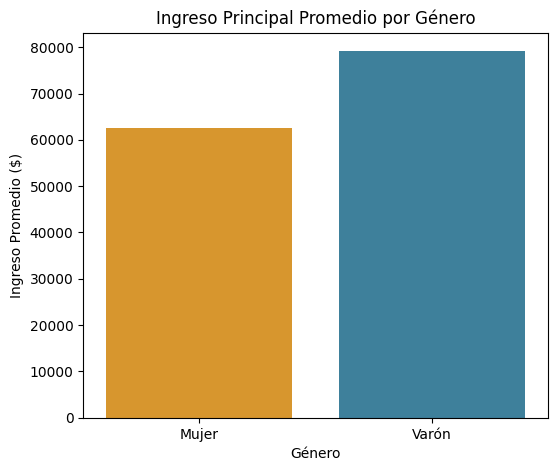

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Promedio por género
ingreso_prom = df_reg.groupby('Género')['Ingreso Principal'].mean().reset_index()

 #Paleta invertida

palette_dict = {
    
    'Varón': '#2E86AB' ,   # ahora usa el naranja
  
    'Mujer': '#F39C12'  #F39C12',     #F39C12'
}

plt.figure(figsize=(6,5))
sns.barplot(
    x='Género',
    y='Ingreso Principal',
    data=ingreso_prom,
    palette=palette_dict
)

plt.ylabel('Ingreso Promedio ($)')
plt.title('Ingreso Principal Promedio por Género')
plt.show()


In [29]:
print(df_reg.columns)


Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Género', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo empleador', 'Descuento jubilatorio', 'Años Educacion',
       'Experiencia Potencial', 'Experiencia Potencial Cuadrado',
       'Edad_Cuadrado', 'Ingreso Principal', 'ITF', 'Provincia',
       'Informalidad_laboral'],
      dtype='object')


In [42]:
df_reg['Categoria Ocupacional'].value_counts()


Obrero o empleado    474429
Cuenta propia        127953
Patrón                20203
Name: Categoria Ocupacional, dtype: int64

In [31]:
df_reg= df_reg[(df_reg['ANO4'] >= 2015) & (df_reg['ANO4'] <= 2024)].copy()

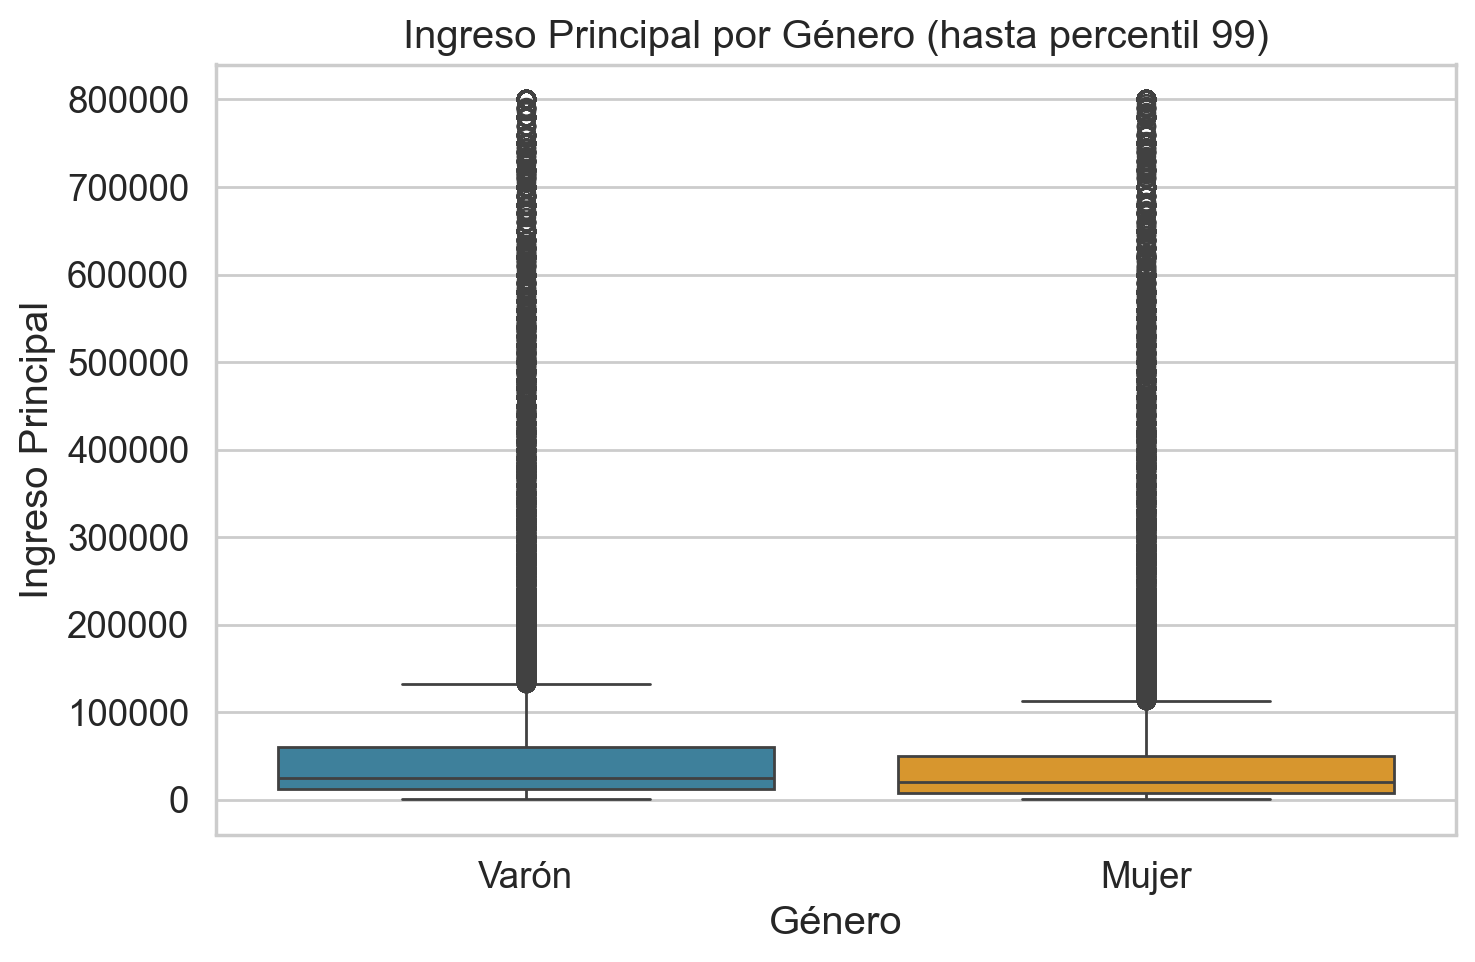

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo profesional
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.dpi'] = 200

# ---------------------------
# Boxplot Ingreso Principal por Género (escala lineal, recortando outliers extremos)
# ---------------------------
plt.figure(figsize=(8,5))

# Limitar ingresos hasta percentil 99
limite_y = df_reg['Ingreso Principal'].quantile(0.99)

sns.boxplot(
    x='Género', 
    y='Ingreso Principal', 
    data=df_reg[df_reg['Ingreso Principal'] <= limite_y],
    palette=["#2E86AB","#F39C12"]
)

plt.title("Ingreso Principal por Género (hasta percentil 99)")
plt.ylabel("Ingreso Principal")
plt.xlabel("Género")
plt.show()


In [31]:
df_reg.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Género,Edad,Nacionalidad,Maximo Nivel Educativo,...,Tipo empleador,Descuento jubilatorio,Años Educacion,Experiencia Potencial,Experiencia Potencial Cuadrado,Edad_Cuadrado,Ingreso Principal,ITF,Provincia,Informalidad_laboral
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Privada,No,7,7,49,400,1500.0000,0.0,Buenos Aires,Informal
1,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Estatal,Sí,12,46,2116,4096,9500.0000,9500.0,Buenos Aires,Formal
2,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Privada,Sí,13,5,25,576,8000.0000,0.0,Buenos Aires,Formal
3,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,42,En país limítrofe,2,...,Privada,0,7,29,841,1764,6000.0000,6000.0,Buenos Aires,NaN
4,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,59,En esta localidad,7,...,Privada,No,17,36,1296,3481,14000.0000,21000.0,Buenos Aires,Informal
5,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,41,En esta localidad,6,...,Estatal,Sí,17,18,324,1681,9000.0000,0.0,Buenos Aires,Formal
6,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,49,En otra localidad de esta provincia,4,...,Privada,0,10,33,1089,2401,20000.0000,0.0,Buenos Aires,NaN
7,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,Privada,Sí,12,29,841,2209,15000.0000,0.0,Buenos Aires,Formal
8,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,58,En otra localidad de esta provincia,7,...,Estatal,Sí,17,35,1225,3364,24000.0000,0.0,Buenos Aires,Formal
9,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Varón,52,En esta localidad,4,...,de otro tipo,Sí,12,34,1156,2704,23000.0000,29000.0,Buenos Aires,Formal


In [32]:
# Renombrar df_reg a df_informal
df_informal = df_reg.copy()


In [33]:
print(df_informal.columns)

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Género', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo empleador', 'Descuento jubilatorio', 'Años Educacion',
       'Experiencia Potencial', 'Experiencia Potencial Cuadrado',
       'Edad_Cuadrado', 'Ingreso Principal', 'ITF', 'Provincia',
       'Informalidad_laboral'],
      dtype='object')


In [34]:
df_informal.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Género,Edad,Nacionalidad,Maximo Nivel Educativo,...,Tipo empleador,Descuento jubilatorio,Años Educacion,Experiencia Potencial,Experiencia Potencial Cuadrado,Edad_Cuadrado,Ingreso Principal,ITF,Provincia,Informalidad_laboral
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Privada,No,7,7,49,400,1500.0000,0.0,Buenos Aires,Informal
1,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Estatal,Sí,12,46,2116,4096,9500.0000,9500.0,Buenos Aires,Formal
2,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Privada,Sí,13,5,25,576,8000.0000,0.0,Buenos Aires,Formal
3,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,42,En país limítrofe,2,...,Privada,0,7,29,841,1764,6000.0000,6000.0,Buenos Aires,NaN
4,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,59,En esta localidad,7,...,Privada,No,17,36,1296,3481,14000.0000,21000.0,Buenos Aires,Informal
5,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,41,En esta localidad,6,...,Estatal,Sí,17,18,324,1681,9000.0000,0.0,Buenos Aires,Formal
6,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario incompleto,Varón,49,En otra localidad de esta provincia,4,...,Privada,0,10,33,1089,2401,20000.0000,0.0,Buenos Aires,NaN
7,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,Privada,Sí,12,29,841,2209,15000.0000,0.0,Buenos Aires,Formal
8,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario completo,Mujer,58,En otra localidad de esta provincia,7,...,Estatal,Sí,17,35,1225,3364,24000.0000,0.0,Buenos Aires,Formal
9,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Varón,52,En esta localidad,4,...,de otro tipo,Sí,12,34,1156,2704,23000.0000,29000.0,Buenos Aires,Formal


In [33]:
df_informal['Nivel Educativo'].value_counts()

Secundario completo         186752
Universitario completo      137413
Secundario incompleto       107174
Universitario incompleto     85154
Primario completo            83569
Primario incompleto          20586
Sin instrucción               1937
Name: Nivel Educativo, dtype: int64

In [34]:
# Columnas del DataFrame
print(df_informal.columns)

# Valores únicos de nivel educativo
print(df_informal['Nivel Educativo'].value_counts(dropna=False))

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Género', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo empleador', 'Descuento jubilatorio', 'Años Educacion',
       'Experiencia Potencial', 'Experiencia Potencial Cuadrado',
       'Edad_Cuadrado', 'Ingreso Principal', 'ITF', 'Provincia',
       'Informalidad_laboral'],
      dtype='object')
Secundario completo         186752
Universitario completo      137413
Secundario incompleto       107174
Universitario incompleto     85154
Primario completo            83569
Primario incompleto          20586
Sin instrucción               1937
Name: Nivel Educativo, dtype: int64


 ## DEFLACTACION DEL DF

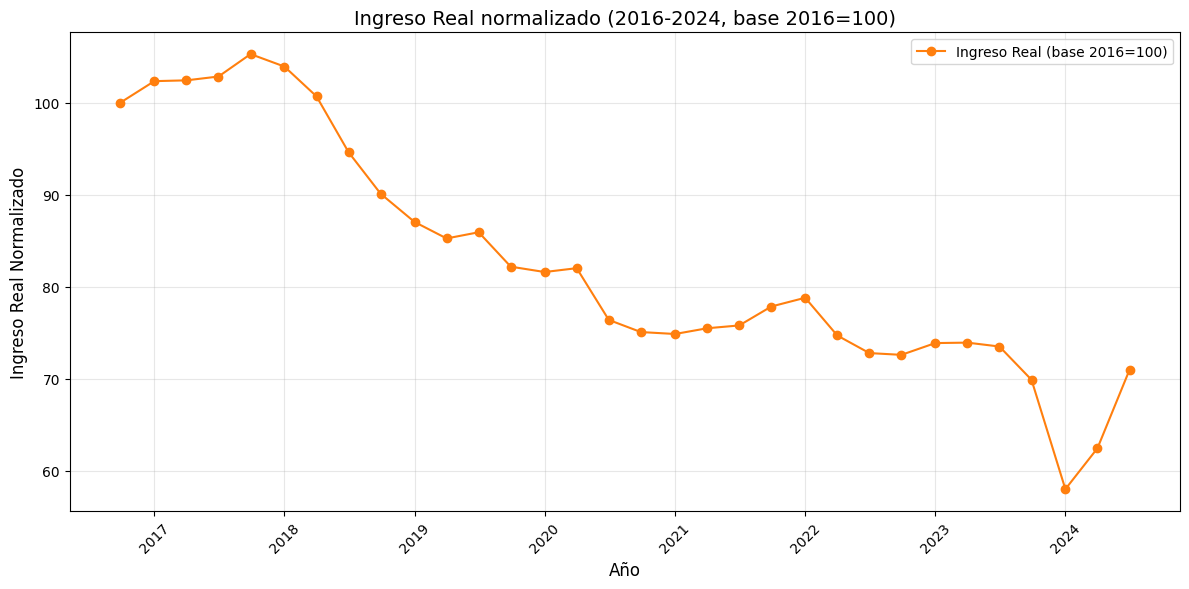

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1️⃣ Crear DataFrame IPC (dic-16 base 100) ---
meses = ['dic-16',
    'ene-17','feb-17','mar-17','abr-17','may-17','jun-17','jul-17','ago-17','sep-17','oct-17','nov-17','dic-17',
    'ene-18','feb-18','mar-18','abr-18','may-18','jun-18','jul-18','ago-18','sep-18','oct-18','nov-18','dic-18',
    'ene-19','feb-19','mar-19','abr-19','may-19','jun-19','jul-19','ago-19','sep-19','oct-19','nov-19','dic-19',
    'ene-20','feb-20','mar-20','abr-20','may-20','jun-20','jul-20','ago-20','sep-20','oct-20','nov-20','dic-20',
    'ene-21','feb-21','mar-21','abr-21','may-21','jun-21','jul-21','ago-21','sep-21','oct-21','nov-21','dic-21',
    'ene-22','feb-22','mar-22','abr-22','may-22','jun-22','jul-22','ago-22','sep-22','oct-22','nov-22','dic-22',
    'ene-23','feb-23','mar-23','abr-23','may-23','jun-23','jul-23','ago-23','sep-23','oct-23','nov-23','dic-23',
    'ene-24','feb-24','mar-24','abr-24','may-24','jun-24','jul-24','ago-24','sep-24','oct-24','nov-24','dic-24',
    'ene-25','feb-25','mar-25','abr-25','may-25','jun-25','jul-25','ago-25','sep-25','oct-25','nov-25','dic-25',
    'ene-26'
]

ipc_valores = [0, 1.6,2.1,2.4,2.7,1.4,1.2,1.7,1.4,1.9,1.5,1.4,3.1,
               1.8,2.4,2.3,2.7,2.1,3.7,3.1,3.9,6.5,5.4,3.2,2.6,
               2.9,3.8,4.7,3.4,3.1,2.7,2.2,4.0,5.9,3.3,4.3,3.7,
               2.3,2.0,3.3,1.5,1.5,2.2,1.9,2.7,2.8,3.8,3.2,4.0,
               4.0,3.6,4.8,4.1,3.3,3.2,3.0,2.5,3.5,3.5,2.5,3.8,
               3.9,4.7,6.7,6.0,5.1,5.3,7.4,7.0,6.2,6.3,4.9,5.1,
               6.0,6.6,7.7,8.4,7.8,6.0,6.3,12.4,12.7,8.3,12.8,25.5,
               20.6,13.2,11.0,8.8,4.2,4.6,4.0,4.2,3.5,2.7,2.4,2.7,
               2.2,2.4,3.7,2.8,1.5,1.6,1.9,1.9,2.1,2.3,2.5,2.8,2.9
              ]

df_ipc = pd.DataFrame({'Mes': meses, 'Inflacion': ipc_valores})
df_ipc['Inflacion'] = df_ipc['Inflacion'] / 100  # pasar a decimal

# Calcular IPC acumulado y factor de deflactación
df_ipc['IPC'] = 100 * (1 + df_ipc['Inflacion']).cumprod()
df_ipc['Factor_Deflactacion'] = 100 / df_ipc['IPC']

# Extraer año y trimestre
mes_dict = {'ene':1,'feb':2,'mar':3,'abr':4,'may':5,'jun':6,'jul':7,'ago':8,'sep':9,'oct':10,'nov':11,'dic':12}
df_ipc['Ano'] = df_ipc['Mes'].str[-2:].astype(int) + 2000
df_ipc['Mes_Num'] = df_ipc['Mes'].str[:3].map(mes_dict)
df_ipc['Trimestre'] = ((df_ipc['Mes_Num']-1)//3 + 1).astype(int)

# --- 2️⃣ Asegurarse que columnas numéricas en df_informal ---
df_informal['ANO4'] = df_informal['ANO4'].astype(int)
df_informal['TRIMESTRE'] = df_informal['TRIMESTRE'].astype(int)
df_informal['Ingreso Principal'] = df_informal['Ingreso Principal'].astype(float)

# --- 3️⃣ Merge con df_ipc para obtener Factor_Deflactacion ---
df_deflactado = df_informal.merge(
    df_ipc[['Ano','Trimestre','Factor_Deflactacion']],
    left_on=['ANO4','TRIMESTRE'],
    right_on=['Ano','Trimestre'],
    how='left'
)

# --- 4️⃣ Calcular Ingreso Real deflactado ---
df_deflactado['Ingreso_Real'] = df_deflactado['Ingreso Principal'] * df_deflactado['Factor_Deflactacion']

# --- 5️⃣ Agrupar por ANO4 y TRIMESTRE ---
df_agg = df_deflactado.groupby(['ANO4','TRIMESTRE'])[['Ingreso_Real']].mean().reset_index()

# --- 6️⃣ Crear columna de fecha (trimestre medio) ---
df_agg['Fecha'] = pd.to_datetime(df_agg['ANO4'].astype(str)) + pd.to_timedelta((df_agg['TRIMESTRE']-1)*3*30, unit='d')

# --- 7️⃣ Normalizar a base 2016 ---
base_2016 = df_deflactado[df_deflactado['ANO4'] == 2016]['Ingreso_Real'].mean()
df_agg['Ingreso_Real_Normalizado'] = df_agg['Ingreso_Real'] / base_2016 * 100

# --- 8️⃣ Graficar ---
plt.figure(figsize=(12,6))
plt.plot(df_agg['Fecha'], df_agg['Ingreso_Real_Normalizado'], marker='o', color='tab:orange', label='Ingreso Real (base 2016=100)')
plt.title('Ingreso Real normalizado (2016-2024, base 2016=100)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Ingreso Real Normalizado', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
df_deflactado.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Género,Edad,Nacionalidad,Maximo Nivel Educativo,...,Experiencia Potencial Cuadrado,Edad_Cuadrado,Ingreso Principal,ITF,Provincia,Informalidad_laboral,Ano,Trimestre,Factor_Deflactacion,Ingreso_Real
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,49,400,1500.0000,0.0,Buenos Aires,Informal,2017.0000,1.0000,0.9843,1476.3780
1,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,49,400,1500.0000,0.0,Buenos Aires,Informal,2017.0000,1.0000,0.9640,1446.0117
2,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,49,400,1500.0000,0.0,Buenos Aires,Informal,2017.0000,1.0000,0.9414,1412.1208
3,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,2116,4096,9500.0000,9500.0,Buenos Aires,Formal,2017.0000,1.0000,0.9843,9350.3937
4,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,2116,4096,9500.0000,9500.0,Buenos Aires,Formal,2017.0000,1.0000,0.9640,9158.0741
5,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,2116,4096,9500.0000,9500.0,Buenos Aires,Formal,2017.0000,1.0000,0.9414,8943.4318
6,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,25,576,8000.0000,0.0,Buenos Aires,Formal,2017.0000,1.0000,0.9843,7874.0157
7,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,25,576,8000.0000,0.0,Buenos Aires,Formal,2017.0000,1.0000,0.9640,7712.0624
8,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,25,576,8000.0000,0.0,Buenos Aires,Formal,2017.0000,1.0000,0.9414,7531.3110
9,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,42,En país limítrofe,2,...,841,1764,6000.0000,6000.0,Buenos Aires,NaN,2017.0000,1.0000,0.9843,5905.5118


In [37]:
df_deflactado['Nivel Educativo'].value_counts()

Secundario completo         514134
Universitario completo      378779
Secundario incompleto       294092
Universitario incompleto    235224
Primario completo           224993
Primario incompleto          55790
Sin instrucción               5331
Name: Nivel Educativo, dtype: int64

In [37]:
print(df_deflactado.columns)

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Género', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo empleador', 'Descuento jubilatorio', 'Años Educacion',
       'Experiencia Potencial', 'Experiencia Potencial Cuadrado',
       'Edad_Cuadrado', 'Ingreso Principal', 'ITF', 'Provincia',
       'Informalidad_laboral', 'Ano', 'Trimestre', 'Factor_Deflactacion',
       'Ingreso_Real'],
      dtype='object')


In [38]:
df_deflactado['Estado'].value_counts()

Ocupado    1708343
Name: Estado, dtype: int64

## Contrucción salario por hora

In [39]:
### Solo ocupadas asalariados  

In [41]:
df_deflactado["Horas trabajadas"] = pd.to_numeric(
    df_deflactado["Horas trabajadas"],
    errors="coerce"
)

In [42]:
df_deflactado["Horas trabajadas"].dtype

dtype('float64')

In [43]:
df_deflactado["Horas trabajadas"].isna().sum()

801

In [44]:
df = df_deflactado[
    (df_deflactado["Estado"] == "Ocupado") &
    (df_deflactado["Ingreso_Real"] > 0) &
    (df_deflactado["Horas trabajadas"] > 0)
]

In [52]:
df["Horas trabajadas"].describe()

count   1563069.0000
mean         36.8209
std          21.1374
min           1.0000
25%          25.0000
50%          40.0000
75%          48.0000
max         999.0000
Name: Horas trabajadas, dtype: float64

In [53]:
df = df[df["Horas trabajadas"] < 99]

In [54]:
df["Horas trabajadas"].describe()

count   1560455.0000
mean         36.5169
std          15.9280
min           1.0000
25%          25.0000
50%          40.0000
75%          48.0000
max          98.0000
Name: Horas trabajadas, dtype: float64

In [55]:
### Construir horas mensuales 

In [56]:
df["Horas_mes"] = df["Horas trabajadas"] * 4.33

In [57]:
### Construir salario horario real 

In [58]:
df["Salario_hora_real"] = df["Ingreso_Real"] / df["Horas_mes"]

In [59]:
df["Salario_hora_real"].describe(percentiles=[0.01,0.05,0.95,0.99])

count   1560455.0000
mean         62.0045
std          62.3473
min           0.0679
1%            6.2923
5%           13.2692
50%          48.4651
95%         151.3044
99%         261.3820
max        8001.4413
Name: Salario_hora_real, dtype: float64

In [60]:
p1 = df["Salario_hora_real"].quantile(0.01)
p99 = df["Salario_hora_real"].quantile(0.99)

df["Salario_hora_real_w"] = df["Salario_hora_real"].clip(p1, p99)

In [61]:
df["log_salario_hora"] = np.log(df["Salario_hora_real_w"])

In [62]:
df["log_salario_hora"].describe()

count   1560455.0000
mean          3.8512
std           0.7269
min           1.8393
25%           3.3962
50%           3.8808
75%           4.3346
max           5.5660
Name: log_salario_hora, dtype: float64

In [63]:
import numpy as np
import pandas as pd

# 1️⃣ Copia del dataframe original
df_mincer = df_deflactado.copy()

# 2️⃣ Asegurar que horas sean numéricas
df_mincer["Horas trabajadas"] = pd.to_numeric(
    df_mincer["Horas trabajadas"], errors="coerce"
)

# 3️⃣ Filtrar muestra válida
df_mincer = df_mincer[
    (df_mincer["Estado"] == "Ocupado") &
    (df_mincer["Ingreso_Real"] > 0) &
    (df_mincer["Horas trabajadas"] > 0) &
    (df_mincer["Horas trabajadas"] < 99)
]

# 4️⃣ Construir horas mensuales
df_mincer["Horas_mes"] = df_mincer["Horas trabajadas"] * 4.33

# 5️⃣ Construir salario horario real
df_mincer["Salario_hora_real"] = (
    df_mincer["Ingreso_Real"] / df_mincer["Horas_mes"]
)

# 6️⃣ Winsorización 1% - 99%
p1 = df_mincer["Salario_hora_real"].quantile(0.01)
p99 = df_mincer["Salario_hora_real"].quantile(0.99)

df_mincer["Salario_hora_real_w"] = (
    df_mincer["Salario_hora_real"].clip(p1, p99)
)

# 7️⃣ Log salario horario
df_mincer["log_salario_hora"] = np.log(
    df_mincer["Salario_hora_real_w"]
)

print("DataFrame listo:", df_mincer.shape)

DataFrame listo: (1560455, 37)


In [64]:
df_mincer.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Género,Edad,Nacionalidad,Maximo Nivel Educativo,...,Provincia,Informalidad_laboral,Ano,Trimestre,Factor_Deflactacion,Ingreso_Real,Horas_mes,Salario_hora_real,Salario_hora_real_w,log_salario_hora
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Buenos Aires,Informal,2017.0000,1.0000,0.9843,1476.3780,207.8400,7.1034,7.1034,1.9606
1,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Buenos Aires,Informal,2017.0000,1.0000,0.9640,1446.0117,207.8400,6.9573,6.9573,1.9398
2,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Buenos Aires,Informal,2017.0000,1.0000,0.9414,1412.1208,207.8400,6.7943,6.7943,1.9161
3,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9843,9350.3937,129.9000,71.9815,71.9815,4.2764
4,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9640,9158.0741,129.9000,70.5010,70.5010,4.2556
5,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9414,8943.4318,129.9000,68.8486,68.8486,4.2319
6,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Buenos Aires,Formal,2017.0000,1.0000,0.9843,7874.0157,103.9200,75.7700,75.7700,4.3277
7,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Buenos Aires,Formal,2017.0000,1.0000,0.9640,7712.0624,103.9200,74.2115,74.2115,4.3069
8,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Buenos Aires,Formal,2017.0000,1.0000,0.9414,7531.3110,103.9200,72.4722,72.4722,4.2832
9,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,42,En país limítrofe,2,...,Buenos Aires,NaN,2017.0000,1.0000,0.9843,5905.5118,173.2000,34.0965,34.0965,3.5292


In [65]:
df_mincer.columns

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Género', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo empleador', 'Descuento jubilatorio', 'Años Educacion',
       'Experiencia Potencial', 'Experiencia Potencial Cuadrado',
       'Edad_Cuadrado', 'Ingreso Principal', 'ITF', 'Provincia',
       'Informalidad_laboral', 'Ano', 'Trimestre', 'Factor_Deflactacion',
       'Ingreso_Real', 'Horas_mes', 'Salario_hora_real', 'Salario_hora_real_w',
       'log_salario_hora'],
      dtype='object')

In [66]:
df_mincer["Informalidad_laboral"].value_counts(dropna=False)

Formal      753636
Informal    419894
NaN         386925
Name: Informalidad_laboral, dtype: int64

In [67]:
pd.crosstab(
    df_mincer["Categoria Ocupacional"],
    df_mincer["Informalidad_laboral"],
    margins=True
)

Informalidad_laboral,Formal,Informal,All
Categoria Ocupacional,,,
Cuenta propia,0,10,10
Obrero o empleado,753636,419884,1173520
All,753636,419894,1173530


In [68]:
df_mincer = df_mincer[
    df_mincer["Categoria Ocupacional"] == "Obrero o empleado"
]

In [69]:
df_mincer["Informalidad_laboral"].value_counts()

Formal      753636
Informal    419884
Name: Informalidad_laboral, dtype: int64

In [70]:
df_mincer.head(20)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Género,Edad,Nacionalidad,Maximo Nivel Educativo,...,Provincia,Informalidad_laboral,Ano,Trimestre,Factor_Deflactacion,Ingreso_Real,Horas_mes,Salario_hora_real,Salario_hora_real_w,log_salario_hora
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Buenos Aires,Informal,2017.0000,1.0000,0.9843,1476.3780,207.8400,7.1034,7.1034,1.9606
1,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Buenos Aires,Informal,2017.0000,1.0000,0.9640,1446.0117,207.8400,6.9573,6.9573,1.9398
2,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Buenos Aires,Informal,2017.0000,1.0000,0.9414,1412.1208,207.8400,6.7943,6.7943,1.9161
3,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9843,9350.3937,129.9000,71.9815,71.9815,4.2764
4,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9640,9158.0741,129.9000,70.5010,70.5010,4.2556
5,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9414,8943.4318,129.9000,68.8486,68.8486,4.2319
6,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Buenos Aires,Formal,2017.0000,1.0000,0.9843,7874.0157,103.9200,75.7700,75.7700,4.3277
7,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Buenos Aires,Formal,2017.0000,1.0000,0.9640,7712.0624,103.9200,74.2115,74.2115,4.3069
8,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Buenos Aires,Formal,2017.0000,1.0000,0.9414,7531.3110,103.9200,72.4722,72.4722,4.2832
21,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9843,14763.7795,173.2000,85.2412,85.2412,4.4455


In [71]:

df_asalariados=df_mincer.copy()

In [72]:
df_asalariados.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel Educativo,Género,Edad,Nacionalidad,Maximo Nivel Educativo,...,Provincia,Informalidad_laboral,Ano,Trimestre,Factor_Deflactacion,Ingreso_Real,Horas_mes,Salario_hora_real,Salario_hora_real_w,log_salario_hora
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Buenos Aires,Informal,2017.0000,1.0000,0.9843,1476.3780,207.8400,7.1034,7.1034,1.9606
1,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Buenos Aires,Informal,2017.0000,1.0000,0.9640,1446.0117,207.8400,6.9573,6.9573,1.9398
2,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,Buenos Aires,Informal,2017.0000,1.0000,0.9414,1412.1208,207.8400,6.7943,6.7943,1.9161
3,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9843,9350.3937,129.9000,71.9815,71.9815,4.2764
4,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9640,9158.0741,129.9000,70.5010,70.5010,4.2556
5,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9414,8943.4318,129.9000,68.8486,68.8486,4.2319
6,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Buenos Aires,Formal,2017.0000,1.0000,0.9843,7874.0157,103.9200,75.7700,75.7700,4.3277
7,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Buenos Aires,Formal,2017.0000,1.0000,0.9640,7712.0624,103.9200,74.2115,74.2115,4.3069
8,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,Buenos Aires,Formal,2017.0000,1.0000,0.9414,7531.3110,103.9200,72.4722,72.4722,4.2832
21,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,47,En esta localidad,4,...,Buenos Aires,Formal,2017.0000,1.0000,0.9843,14763.7795,173.2000,85.2412,85.2412,4.4455


In [74]:
df_asalariados.columns

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Género', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'PONDIIO', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo empleador', 'Descuento jubilatorio', 'Años Educacion',
       'Experiencia Potencial', 'Experiencia Potencial Cuadrado',
       'Edad_Cuadrado', 'Ingreso Principal', 'ITF', 'Provincia',
       'Informalidad_laboral', 'Ano', 'Trimestre', 'Factor_Deflactacion',
       'Ingreso_Real', 'Horas_mes', 'Salario_hora_real', 'Salario_hora_real_w',
       'log_salario_hora'],
      dtype='object')

## Variables seleccionadas del modelo

In [225]:
df_deflactado['log_ingreso'] = np.log(df_deflactado['Ingreso_Real'])

In [55]:
variables_modelo = [
    'Ingreso_Real',                    # Variable dependiente
    'Experiencia Potencial', 
    'Experiencia Potencial Cuadrado', 
    'Nivel Educativo',
    'Género',
    'Categoria Ocupacional',
    'Tipo empleador',
    'Informalidad_laboral',
    'Region',
    'ANO4',
    'PONDERA'
]


In [75]:
df_deflactado.head(10)

,ANO4,TRIMESTRE,Region,AGLOMERADO,Estado,Nivel_Educativo,Genero,Edad,Nacionalidad,Maximo Nivel Educativo,...,Ingreso Principal,ITF,Provincia,informal,Ano,Trimestre,Factor_Deflactacion,Ingreso_Real,log_ingreso,edu_informal
0,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,1500.0000,0.0,Buenos Aires,Informal,2017.0000,1.0000,0.9843,1476.3780,7.2973,InformalInformalInformalInformalInformalInform...
1,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,1500.0000,0.0,Buenos Aires,Informal,2017.0000,1.0000,0.9640,1446.0117,7.2766,InformalInformalInformalInformalInformalInform...
2,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,20,En esta localidad,2,...,1500.0000,0.0,Buenos Aires,Informal,2017.0000,1.0000,0.9414,1412.1208,7.2528,InformalInformalInformalInformalInformalInform...
3,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,9500.0000,9500.0,Buenos Aires,Formal,2017.0000,1.0000,0.9843,9350.3937,9.1432,FormalFormalFormalFormalFormalFormalFormalForm...
4,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,9500.0000,9500.0,Buenos Aires,Formal,2017.0000,1.0000,0.9640,9158.0741,9.1224,FormalFormalFormalFormalFormalFormalFormalForm...
5,2017,1,Pampeana,Gran La Plata,Ocupado,Secundario completo,Mujer,64,En esta localidad,4,...,9500.0000,9500.0,Buenos Aires,Formal,2017.0000,1.0000,0.9414,8943.4318,9.0987,FormalFormalFormalFormalFormalFormalFormalForm...
6,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,8000.0000,0.0,Buenos Aires,Formal,2017.0000,1.0000,0.9843,7874.0157,8.9713,FormalFormalFormalFormalFormalFormalFormalForm...
7,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,8000.0000,0.0,Buenos Aires,Formal,2017.0000,1.0000,0.9640,7712.0624,8.9505,FormalFormalFormalFormalFormalFormalFormalForm...
8,2017,1,Pampeana,Gran La Plata,Ocupado,Universitario incompleto,Mujer,24,En otra localidad de esta provincia,7,...,8000.0000,0.0,Buenos Aires,Formal,2017.0000,1.0000,0.9414,7531.3110,8.9268,FormalFormalFormalFormalFormalFormalFormalForm...
9,2017,1,Pampeana,Gran La Plata,Ocupado,Primario completo,Varón,42,En país limítrofe,2,...,6000.0000,6000.0,Buenos Aires,NaN,2017.0000,1.0000,0.9843,5905.5118,8.6836,NaN


## ESTIMACION EFECTOS FIJOS TEMPORALES ## 

In [73]:
print(df_deflactado.columns)

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel_Educativo', 'Genero', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo empleador', 'Descuento jubilatorio', 'Años Educacion',
       'Experiencia_Potencial', 'Experiencia_Potencial_Cuadrado',
       'Edad_Cuadrado', 'Ingreso Principal', 'ITF', 'Provincia', 'informal',
       'Ano', 'Trimestre', 'Factor_Deflactacion', 'Ingreso_Real',
       'log_ingreso', 'edu_informal'],
      dtype='object')


In [89]:
import numpy as np

# Crear log_ingreso a partir del Ingreso_Real
df_deflactado['log_ingreso'] = np.log(df_deflactado['Ingreso_Real'].replace(0, np.nan))

# Ahora renombramos columnas para que Patsy las acepte
df_deflactado = df_deflactado.rename(columns={
    'Nivel Educativo': 'Nivel_Educativo',
    'Experiencia Potencial': 'Experiencia_Potencial',
    'Experiencia Potencial Cuadrado': 'Experiencia_Potencial_Cuadrado',
    'Categoria Ocupacional': 'Categoria_Ocupacional',
    'Género': 'Genero'
})

import statsmodels.formula.api as smf

# --- WLS con ponderación PONDERA ---
modelo_wls = smf.wls(
    formula="""
    log_ingreso ~ 
    Nivel_Educativo +
    Experiencia_Potencial +
    Experiencia_Potencial_Cuadrado +
    Informalidad_laboral +
    C(Genero) +
    C(Categoria_Ocupacional) +
    C(Region) +
    C(ANO4)
    """,
    data=df_deflactado,
    weights=df_deflactado['PONDERA']
).fit(cov_type='HC1')  # errores robustos a heterocedasticidad

print(modelo_wls.summary())

C:\Users\acer_\AppData\Roaming\Python\Python39\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 25
  warnings.warn('covariance of constraints does not have full '


                            WLS Regression Results                            
Dep. Variable:            log_ingreso   R-squared:                       0.469
Model:                            WLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                 9.329e+06
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        01:59:07   Log-Likelihood:            -1.4832e+06
No. Observations:             1251444   AIC:                         2.966e+06
Df Residuals:                 1251419   BIC:                         2.967e+06
Df Model:                          24                                         
Covariance Type:                  HC1                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [91]:
modelo_wls_cluster = smf.wls(
    formula="""
    log_ingreso ~ 
    Nivel_Educativo +
    Experiencia_Potencial +
    Experiencia_Potencial_Cuadrado +
    Informalidad_laboral +
    C(Genero) +
    C(Categoria_Ocupacional) +
    C(Region) +
    C(ANO4)
    """,
    data=df_deflactado,
    weights=df_deflactado['PONDERA']
).fit(cov_type='cluster', cov_kwds={'groups': df_deflactado['Region']})

print(modelo_wls_cluster.summary())

ValueError: The weights and list don't have the same length.

In [78]:
import statsmodels.formula.api as smf

# --- WLS con ponderación PONDERA ---
modelo_wls = smf.wls(
    formula="""
    log_ingreso ~ 
    Nivel_Educativo +
    Experiencia_Potencial +
    Experiencia_Potencial_Cuadrado +
    informal +
    edu_informal +
    C(Genero) +
    C(`Categoria Ocupacional`) +
    C(Region) +
    C(ANO4)
    """,
    data=df_deflactado,
    weights=df_deflactado['PONDERA']
).fit(cov_type='HC1')  # errores robustos a heterocedasticidad

print(modelo_wls.summary())

PatsyError: error tokenizing input (maybe an unclosed string?)
    log_ingreso ~      Nivel_Educativo +     Experiencia_Potencial +     Experiencia_Potencial_Cuadrado +     informal +     edu_informal +     C(Genero) +     C(`Categoria Ocupacional`) +     C(Region) +     C(ANO4)
                                                                                                                                                                  ^

In [90]:
modelo_base = smf.wls(
    formula = """
    log_ingreso ~ 
    C(Nivel_Educativo, Treatment(reference="Sin instrucción")) +
    Experiencia_Potencial +
    Experiencia_Potencial_Cuadrado +
    informal +
    edu_informal +
    C(Género, Treatment(reference="Mujer")) +
    C(Categoria_Ocupacional, Treatment(reference="Cuenta propia")) +
    C(Region, Treatment(reference="Cuyo")) +
    C(ANO4, Treatment(reference=2015))
    """,
    data = df_deflactado,
    weights = df_deflactado['PONDERA']
).fit(cov_type='HC1')

print(modelo_base.summary())

PatsyError: Error evaluating factor: NameError: name 'Género' is not defined
    log_ingreso ~      C(Nivel_Educativo, Treatment(reference="Sin instrucción")) +     Experiencia_Potencial +     Experiencia_Potencial_Cuadrado +     informal +     edu_informal +     C(Género, Treatment(reference="Mujer")) +     C(Categoria_Ocupacional, Treatment(reference="Cuenta propia")) +     C(Region, Treatment(reference="Cuyo")) +     C(ANO4, Treatment(reference=2015))
                                                                                                                                                                                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [233]:
modelo_genero = smf.wls(
    formula = """
    log_ingreso ~ 
    C(Nivel_Educativo, Treatment(reference="Secundario completo")) * C(Género, Treatment(reference="Mujer")) +
    Experiencia_Potencial +
    Experiencia_Potencial_Cuadrado +
    informal +
    edu_informal +
    C(Categoria_Ocupacional) +
    C(Region) +
    C(ANO4)
    """,
    data = df_deflactado,
    weights = df_deflactado['PONDERA']
).fit(cov_type='HC1')
print(modelo_base.summary())

                            WLS Regression Results                            
Dep. Variable:            log_ingreso   R-squared:                       0.432
Model:                            WLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                 9.007e+06
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        00:33:39   Log-Likelihood:            -2.1345e+06
No. Observations:             1646800   AIC:                         4.269e+06
Df Residuals:                 1646773   BIC:                         4.269e+06
Df Model:                          26                                         
Covariance Type:                  HC1                                         
                                                                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [234]:
import statsmodels.formula.api as smf

modelo_principal = smf.wls(
    formula = """
    log_ingreso ~ 
    C(Nivel_Educativo, Treatment(reference="Secundario completo")) +
    Experiencia_Potencial +
    Experiencia_Potencial_Cuadrado +
    informal +
    edu_informal +
    C(Género, Treatment(reference="Mujer")) +
    C(Categoria_Ocupacional, Treatment(reference="Cuenta propia")) +
    C(Region, Treatment(reference="Cuyo")) +
    C(ANO4, Treatment(reference=2015))
    """,
    data = df_deflactado,
    weights = df_deflactado['PONDERA']
).fit(cov_type='HC1')

print(modelo_principal.summary())

                            WLS Regression Results                            
Dep. Variable:            log_ingreso   R-squared:                       0.432
Model:                            WLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                 9.007e+06
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        00:36:30   Log-Likelihood:            -2.1345e+06
No. Observations:             1646800   AIC:                         4.269e+06
Df Residuals:                 1646773   BIC:                         4.269e+06
Df Model:                          26                                         
Covariance Type:                  HC1                                         
                                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

## Modelo empírico

In [235]:
# 1️⃣ Ya tenés creada Experiencia_Potencial
# df_deflactado["Experiencia_Potencial"] = ...

# 2️⃣ Centrar experiencia
df_deflactado["exp_centrada"] = (
    df_deflactado["Experiencia_Potencial"] -
    df_deflactado["Experiencia_Potencial"].mean()
)

# 3️⃣ Crear el cuadrado centrado
df_deflactado["exp_centrada2"] = df_deflactado["exp_centrada"]**2

In [238]:
modelo_principal = smf.wls(
    formula = """
    log_ingreso ~ 
    C(Nivel_Educativo, Treatment(reference="Secundario completo")) +
    exp_centrada +
    exp_centrada2 +
    informal +
    edu_informal +
    C(Género, Treatment(reference="Mujer")) +
    C(Categoria_Ocupacional, Treatment(reference="Cuenta propia")) +
    C(Region, Treatment(reference="Cuyo")) +
    C(ANO4, Treatment(reference=2015))
    """,
    data = df_deflactado,
    weights = df_deflactado['PONDERA']
).fit(cov_type='HC1')

print(modelo_principal.summary())

                            WLS Regression Results                            
Dep. Variable:            log_ingreso   R-squared:                       0.432
Model:                            WLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                 9.007e+06
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        00:45:12   Log-Likelihood:            -2.1345e+06
No. Observations:             1646800   AIC:                         4.269e+06
Df Residuals:                 1646773   BIC:                         4.269e+06
Df Model:                          26                                         
Covariance Type:                  HC1                                         
                                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

In [239]:
modelo_principal = smf.wls(
    formula = """
    log_ingreso ~ 
    C(Nivel_Educativo, Treatment(reference="Secundario completo")) +
    exp_centrada +
    exp_centrada2 +
    informal +
    C(Género, Treatment(reference="Mujer")) +
    C(Categoria_Ocupacional, Treatment(reference="Cuenta propia")) +
    C(Region, Treatment(reference="Cuyo"))
    """,
    data = df_deflactado,
    weights = df_deflactado['PONDERA']
).fit(cov_type='HC1')

print(modelo_principal.summary())

                            WLS Regression Results                            
Dep. Variable:            log_ingreso   R-squared:                       0.407
Model:                            WLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                 2.657e+04
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        00:48:32   Log-Likelihood:            -2.1699e+06
No. Observations:             1646800   AIC:                         4.340e+06
Df Residuals:                 1646782   BIC:                         4.340e+06
Df Model:                          17                                         
Covariance Type:                  HC1                                         
                                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

In [240]:
modelo_central = smf.wls(
    formula = """
    log_ingreso ~ 
    C(Nivel_Educativo, Treatment(reference="Secundario completo")) *
    informal +
    exp_centrada +
    exp_centrada2 +
    C(Género, Treatment(reference="Mujer")) +
    C(Categoria_Ocupacional, Treatment(reference="Cuenta propia")) +
    C(Region, Treatment(reference="Cuyo"))
    """,
    data = df_deflactado,
    weights = df_deflactado['PONDERA']
).fit(cov_type='HC1')

print(modelo_central.summary())

                            WLS Regression Results                            
Dep. Variable:            log_ingreso   R-squared:                       0.408
Model:                            WLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                 1.977e+04
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        00:54:02   Log-Likelihood:            -2.1683e+06
No. Observations:             1646800   AIC:                         4.337e+06
Df Residuals:                 1646776   BIC:                         4.337e+06
Df Model:                          23                                         
Covariance Type:                  HC1                                         
                                                                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

In [242]:
df_deflactado.columns

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel_Educativo', 'Género', 'Edad', 'Nacionalidad',
       'Maximo_Nivel_Educativo', 'Finalizo_Nivel', 'Ultimo_Ano_Aprobado',
       'Nacionalidad', 'PONDERA', 'Categoria_Ocupacional',
       'Categoria_Inactividad', 'Tiempo_Trabajado', 'Horas_trabajadas',
       'Tipo_empleador', 'Descuento_jubilatorio', 'Anos_Educacion',
       'Experiencia_Potencial', 'Experiencia_Potencial_Cuadrado',
       'Edad_Cuadrado', 'Ingreso_Principal', 'ITF', 'Provincia',
       'Informalidad_laboral', 'Ano', 'Trimestre', 'Factor_Deflactacion',
       'Ingreso_Real', 'log_ingreso', 'informal', 'edu_informal',
       'exp_centrada', 'exp_centrada2'],
      dtype='object')

In [ ]:
df_deflactado["Estado"].value_counts()

Ocupado    1708343
Name: Estado, dtype: int64

In [247]:
# Variables necesarias para el modelo
vars_modelo = [
    "log_ingreso",
    "Nivel_Educativo",
    "informal",
    "exp_centrada",
    "exp_centrada2",
    "Género",
    "Categoria_Ocupacional",
    "Region",
    "PONDERA",
    "AGLOMERADO"
]

# Base limpia sin NA en variables relevantes
df_model = df_deflactado[vars_modelo].dropna()

print("Observaciones usadas en el modelo:", len(df_model))

Observaciones usadas en el modelo: 1646800


In [248]:
import statsmodels.formula.api as smf

modelo_cluster = smf.wls(
    formula = """
    log_ingreso ~ 
    C(Nivel_Educativo, Treatment(reference="Secundario completo")) *
    informal +
    exp_centrada +
    exp_centrada2 +
    C(Género, Treatment(reference="Mujer")) +
    C(Categoria_Ocupacional, Treatment(reference="Cuenta propia")) +
    C(Region, Treatment(reference="Cuyo"))
    """,
    data = df_model,
    weights = df_model["PONDERA"]
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_model["AGLOMERADO"]}
)

print(modelo_cluster.summary())

                            WLS Regression Results                            
Dep. Variable:            log_ingreso   R-squared:                       0.408
Model:                            WLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                 1.527e+04
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           9.44e-57
Time:                        01:08:16   Log-Likelihood:            -2.1683e+06
No. Observations:             1646800   AIC:                         4.337e+06
Df Residuals:                 1646776   BIC:                         4.337e+06
Df Model:                          23                                         
Covariance Type:              cluster                                         
                                                                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

In [1]:
import statsmodels.formula.api as smf

# --- Tomar una muestra de 100.000 ocupados ---
df_sample = df_deflactado.sample(n=100_000, random_state=123)

# --- Fórmula de regresión cuantílica ---
formula = """
log_ingreso ~ 
C(Nivel_Educativo, Treatment(reference="Secundario completo")) *
informal +
exp_centrada + exp_centrada2 +
C(Género, Treatment(reference="Mujer")) +
C(Categoria_Ocupacional, Treatment(reference="Cuenta propia")) +
C(Region, Treatment(reference="Cuyo"))
"""

# --- Lista de cuantiles a estimar ---
cuantiles = [0.25, 0.75]
resultados = {}

for q in cuantiles:
    mod = smf.quantreg(formula, df_sample)
    res = mod.fit(q=q)
    resultados[q] = res
    print(f"\n=== Cuantil {q} ===")
    print(res.summary())

KeyboardInterrupt: 

In [147]:
# --- 1️⃣ Calcular promedio base 2016 usando Ingreso_Real ---
base_2016 = df_deflactado[df_deflactado['ANO4'] == 2016]['Ingreso_Real'].mean()

# --- 2️⃣ Agrupar por año y trimestre ---
df_agg = df_deflactado.groupby(['ANO4','TRIMESTRE'])[['Ingreso_Real']].mean().reset_index()

# --- 3️⃣ Normalizar Ingreso Real ---
df_agg['Ingreso_Real_Normalizado'] = df_agg['Ingreso_Real'] / base_2016 * 100

# --- 4️⃣ Fecha aproximada por trimestre ---
trimestre_inicio = {1:1, 2:4, 3:7, 4:10}
df_agg['Mes'] = df_agg['TRIMESTRE'].map(trimestre_inicio)
df_agg['Fecha'] = pd.to_datetime(df_agg['ANO4'].astype(str) + '-' + df_agg['Mes'].astype(str) + '-15')

# --- 5️⃣ Filtrar 2017-2024 para graficar ---
df_plot = df_agg[(df_agg['ANO4'] >= 2017) & (df_agg['ANO4'] <= 2024)]

# --- 6️⃣ Graficar ---
plt.figure(figsize=(12,6))
plt.plot(df_plot['Fecha'], df_plot['Ingreso_Real_Normalizado'], marker='o', color='tab:orange', label='Ingreso Real (base 2016=100)')
plt.title('Ingreso Real normalizado (2017-2024, base 2016=100)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Ingreso Real Normalizado', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

ValueError: Cannot set a DataFrame with multiple columns to the single column Ingreso_Real_Normalizado

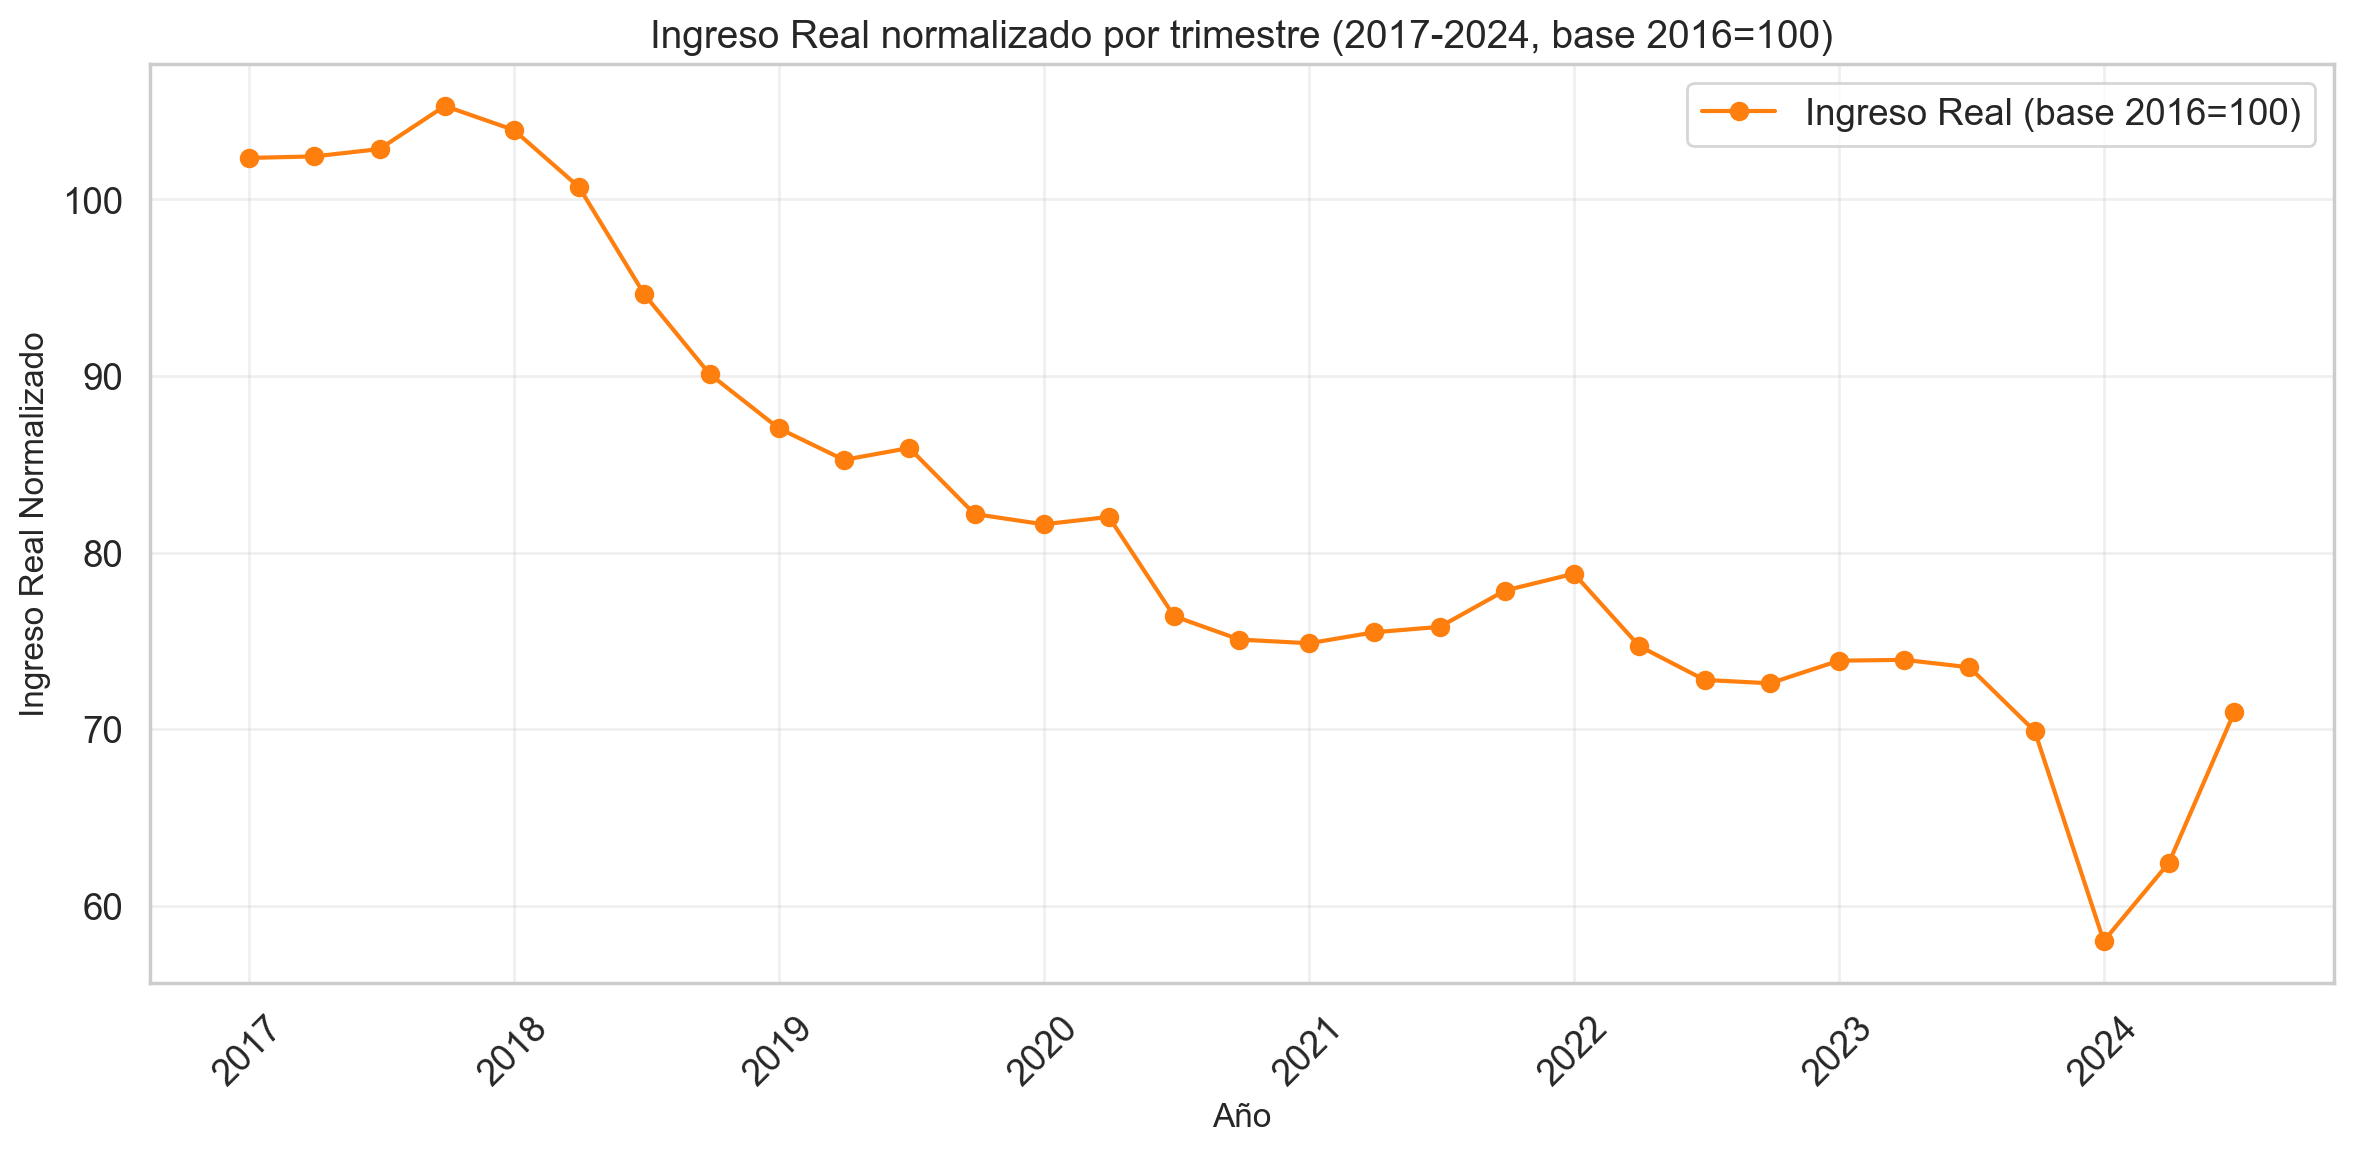

In [171]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1️⃣ Crear DataFrame IPC ---
meses = ['dic-16',
    'ene-17','feb-17','mar-17','abr-17','may-17','jun-17','jul-17','ago-17','sep-17','oct-17','nov-17','dic-17',
    'ene-18','feb-18','mar-18','abr-18','may-18','jun-18','jul-18','ago-18','sep-18','oct-18','nov-18','dic-18',
    'ene-19','feb-19','mar-19','abr-19','may-19','jun-19','jul-19','ago-19','sep-19','oct-19','nov-19','dic-19',
    'ene-20','feb-20','mar-20','abr-20','may-20','jun-20','jul-20','ago-20','sep-20','oct-20','nov-20','dic-20',
    'ene-21','feb-21','mar-21','abr-21','may-21','jun-21','jul-21','ago-21','sep-21','oct-21','nov-21','dic-21',
    'ene-22','feb-22','mar-22','abr-22','may-22','jun-22','jul-22','ago-22','sep-22','oct-22','nov-22','dic-22',
    'ene-23','feb-23','mar-23','abr-23','may-23','jun-23','jul-23','ago-23','sep-23','oct-23','nov-23','dic-23',
    'ene-24','feb-24','mar-24','abr-24','may-24','jun-24','jul-24','ago-24','sep-24','oct-24','nov-24','dic-24',
    'ene-25','feb-25','mar-25','abr-25','may-25','jun-25','jul-25','ago-25','sep-25','oct-25','nov-25','dic-25',
    'ene-26'
]

ipc_valores = [0, 1.6,2.1,2.4,2.7,1.4,1.2,1.7,1.4,1.9,1.5,1.4,3.1,
               1.8,2.4,2.3,2.7,2.1,3.7,3.1,3.9,6.5,5.4,3.2,2.6,
               2.9,3.8,4.7,3.4,3.1,2.7,2.2,4.0,5.9,3.3,4.3,3.7,
               2.3,2.0,3.3,1.5,1.5,2.2,1.9,2.7,2.8,3.8,3.2,4.0,
               4.0,3.6,4.8,4.1,3.3,3.2,3.0,2.5,3.5,3.5,2.5,3.8,
               3.9,4.7,6.7,6.0,5.1,5.3,7.4,7.0,6.2,6.3,4.9,5.1,
               6.0,6.6,7.7,8.4,7.8,6.0,6.3,12.4,12.7,8.3,12.8,25.5,
               20.6,13.2,11.0,8.8,4.2,4.6,4.0,4.2,3.5,2.7,2.4,2.7,
               2.2,2.4,3.7,2.8,1.5,1.6,1.9,1.9,2.1,2.3,2.5,2.8,2.9
              ]

df_ipc = pd.DataFrame({'Mes': meses, 'Inflacion': ipc_valores})
df_ipc['Inflacion'] = df_ipc['Inflacion'] / 100  # pasar a decimal

# Calcular IPC acumulado y factor de deflactación
df_ipc['IPC'] = 100 * (1 + df_ipc['Inflacion']).cumprod()
df_ipc['Factor_Deflactacion'] = 100 / df_ipc['IPC']

# Extraer año y trimestre
mes_dict = {'ene':1,'feb':2,'mar':3,'abr':4,'may':5,'jun':6,'jul':7,'ago':8,'sep':9,'oct':10,'nov':11,'dic':12}
df_ipc['Ano'] = df_ipc['Mes'].str[-2:].astype(int) + 2000
df_ipc['Mes_Num'] = df_ipc['Mes'].str[:3].map(mes_dict)
df_ipc['Trimestre'] = ((df_ipc['Mes_Num']-1)//3 + 1).astype(int)

# --- 2️⃣ Merge con df_informal ---
df_selector = df_informal.merge(
    df_ipc[['Ano','Trimestre','Factor_Deflactacion']],
    left_on=['ANO4','TRIMESTRE'],
    right_on=['Ano','Trimestre'],
    how='left'
)

# --- 3️⃣ Calcular Ingreso Real ---
df_deflactado['Ingreso_Real'] = df_deflactado['Ingreso Principal'] * df_deflactado['Factor_Deflactacion']

# --- 4️⃣ Promedio base 2016 ---
base_2016 = df_deflactado[df_deflactado['ANO4']==2016]['Ingreso_Real'].mean()

# --- 5️⃣ Agrupar por año y trimestre ---
df_agg = df_deflactado.groupby(['ANO4','TRIMESTRE'])['Ingreso_Real'].mean().reset_index()

# --- 6️⃣ Normalizar Ingreso Real ---
df_agg['Ingreso_Real_Normalizado'] = df_agg['Ingreso_Real'] / base_2016 * 100

# --- 7️⃣ Crear fecha por trimestre ---
df_agg['Fecha'] = pd.to_datetime(df_agg['ANO4'].astype(str)) + pd.to_timedelta((df_agg['TRIMESTRE']-1)*3*30, unit='d')

# --- 8️⃣ Filtrar solo 2017-2024 si querés evitar 2016 con datos incompletos ---
df_agg = df_agg[df_agg['ANO4'] >= 2017]

# --- 9️⃣ Graficar ---
plt.figure(figsize=(12,6))
plt.plot(df_agg['Fecha'], df_agg['Ingreso_Real_Normalizado'], marker='o', color='tab:orange', label='Ingreso Real (base 2016=100)')
plt.title('Ingreso Real normalizado por trimestre (2017-2024, base 2016=100)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Ingreso Real Normalizado', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

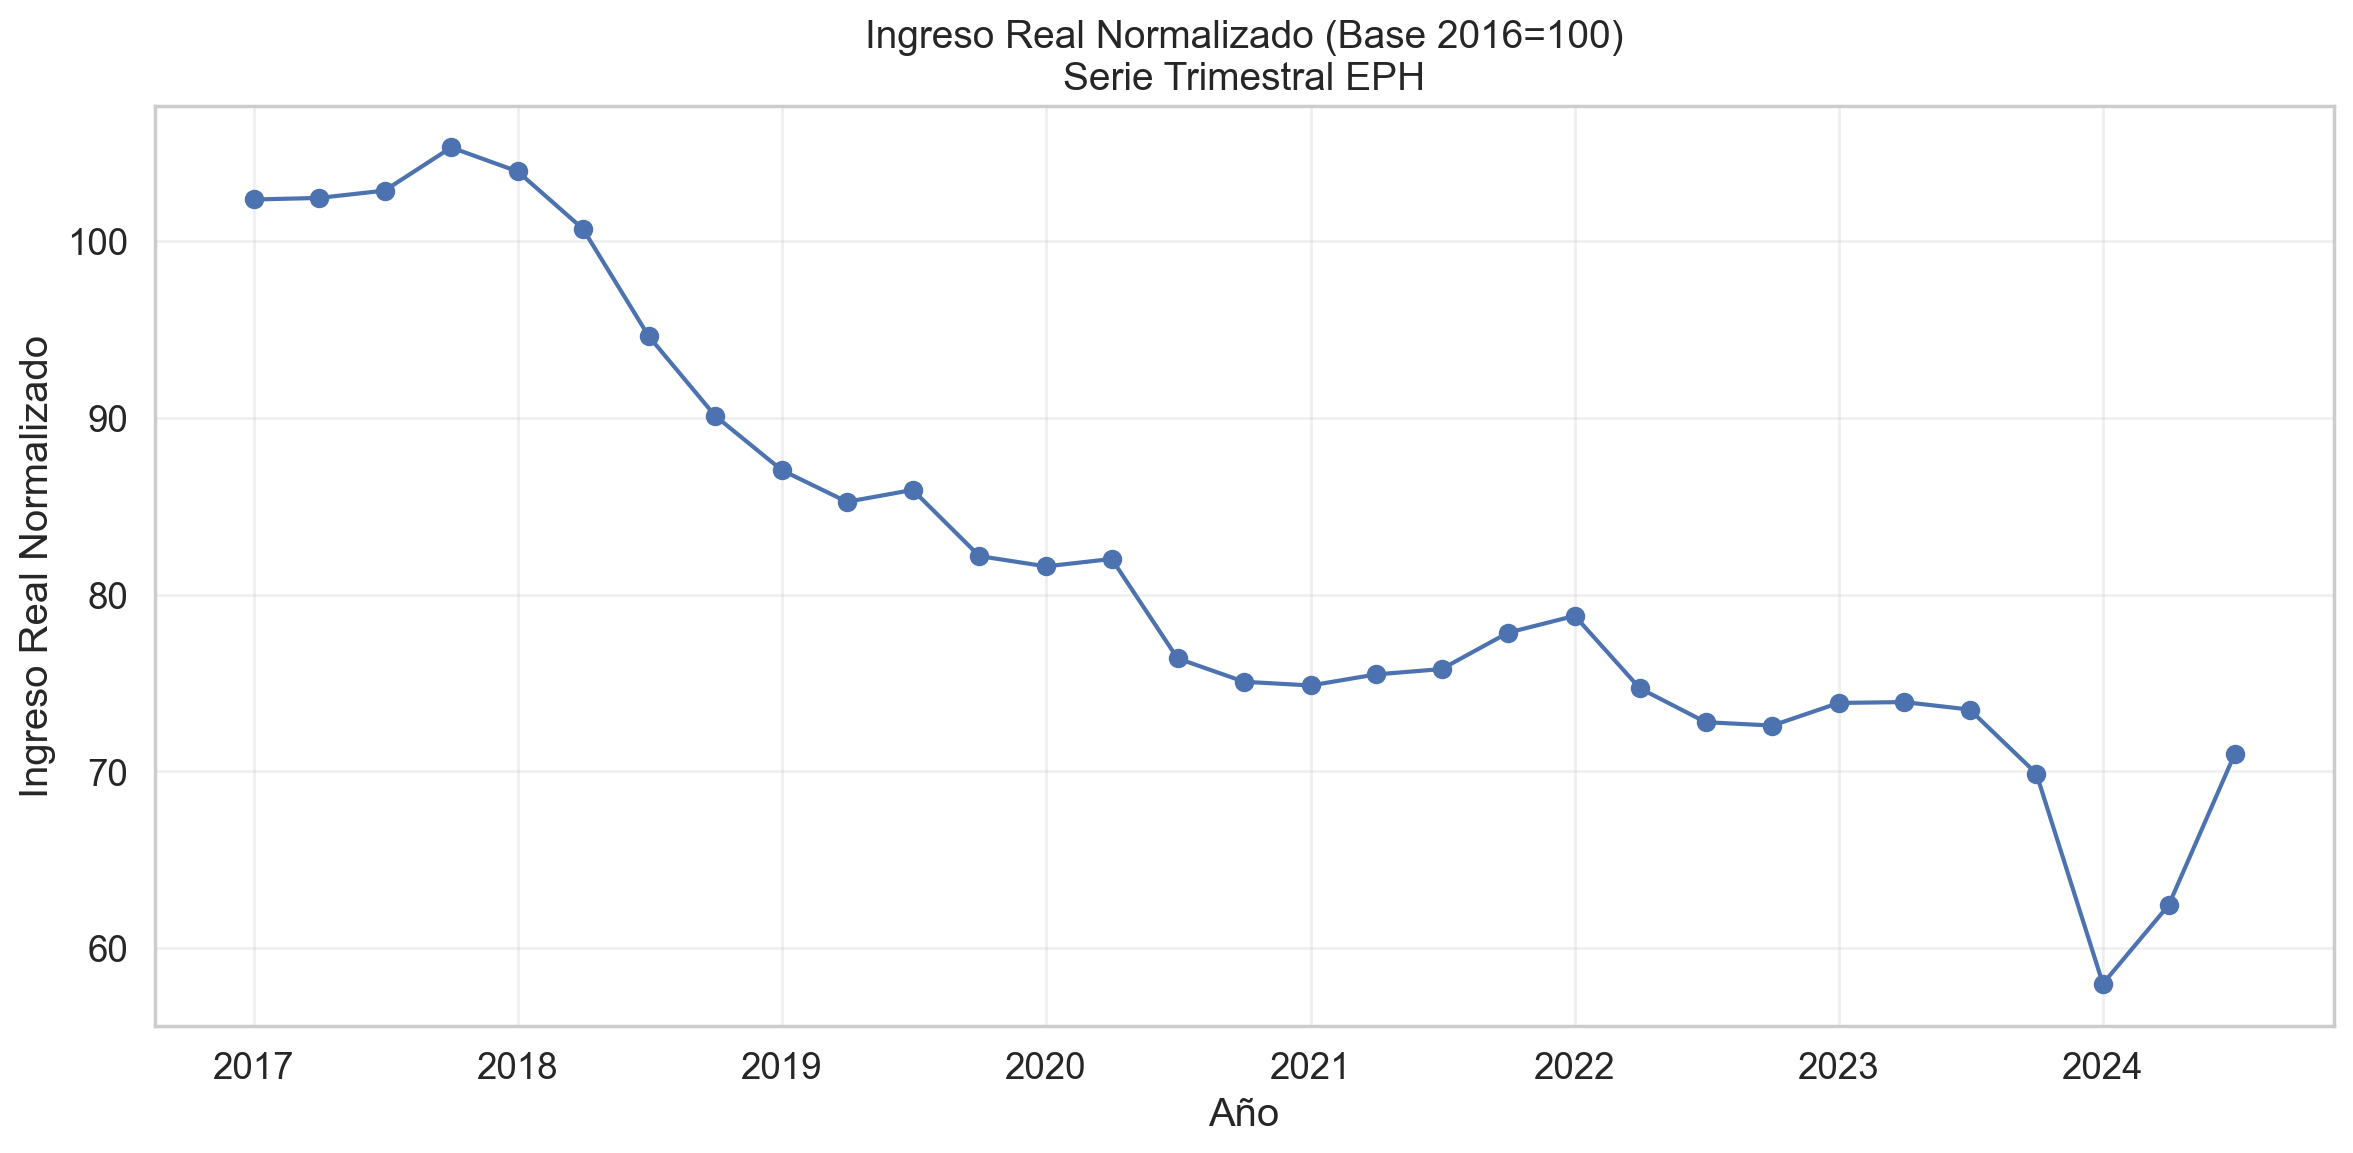

In [153]:
# --- 1️⃣ Agrupar por año y trimestre ---
df_agg = df_deflactado.groupby(['ANO4','TRIMESTRE'])['Ingreso_Real'].mean().reset_index()

# --- 2️⃣ Normalizar base 2016 ---
base_2016 = df_deflactado[df_deflactado['ANO4']==2016]['Ingreso_Real'].mean()
df_agg['Ingreso_Real_Normalizado'] = df_agg['Ingreso_Real'] / base_2016 * 100

# --- 3️⃣ Crear fecha trimestral correcta ---
df_agg['Fecha'] = pd.PeriodIndex(
    year=df_agg['ANO4'],
    quarter=df_agg['TRIMESTRE'],
    freq='Q'
).to_timestamp()

# --- 4️⃣ Ordenar por fecha ---
df_agg = df_agg.sort_values('Fecha')

# --- 5️⃣ Filtrar desde 2017 si querés ---
df_agg = df_agg[df_agg['ANO4'] >= 2017]

# --- 6️⃣ Graficar como serie de tiempo ---
plt.figure(figsize=(12,6))

plt.plot(df_agg['Fecha'],
         df_agg['Ingreso_Real_Normalizado'],
         marker='o')

plt.title('Ingreso Real Normalizado (Base 2016=100)\nSerie Trimestral EPH', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Ingreso Real Normalizado')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

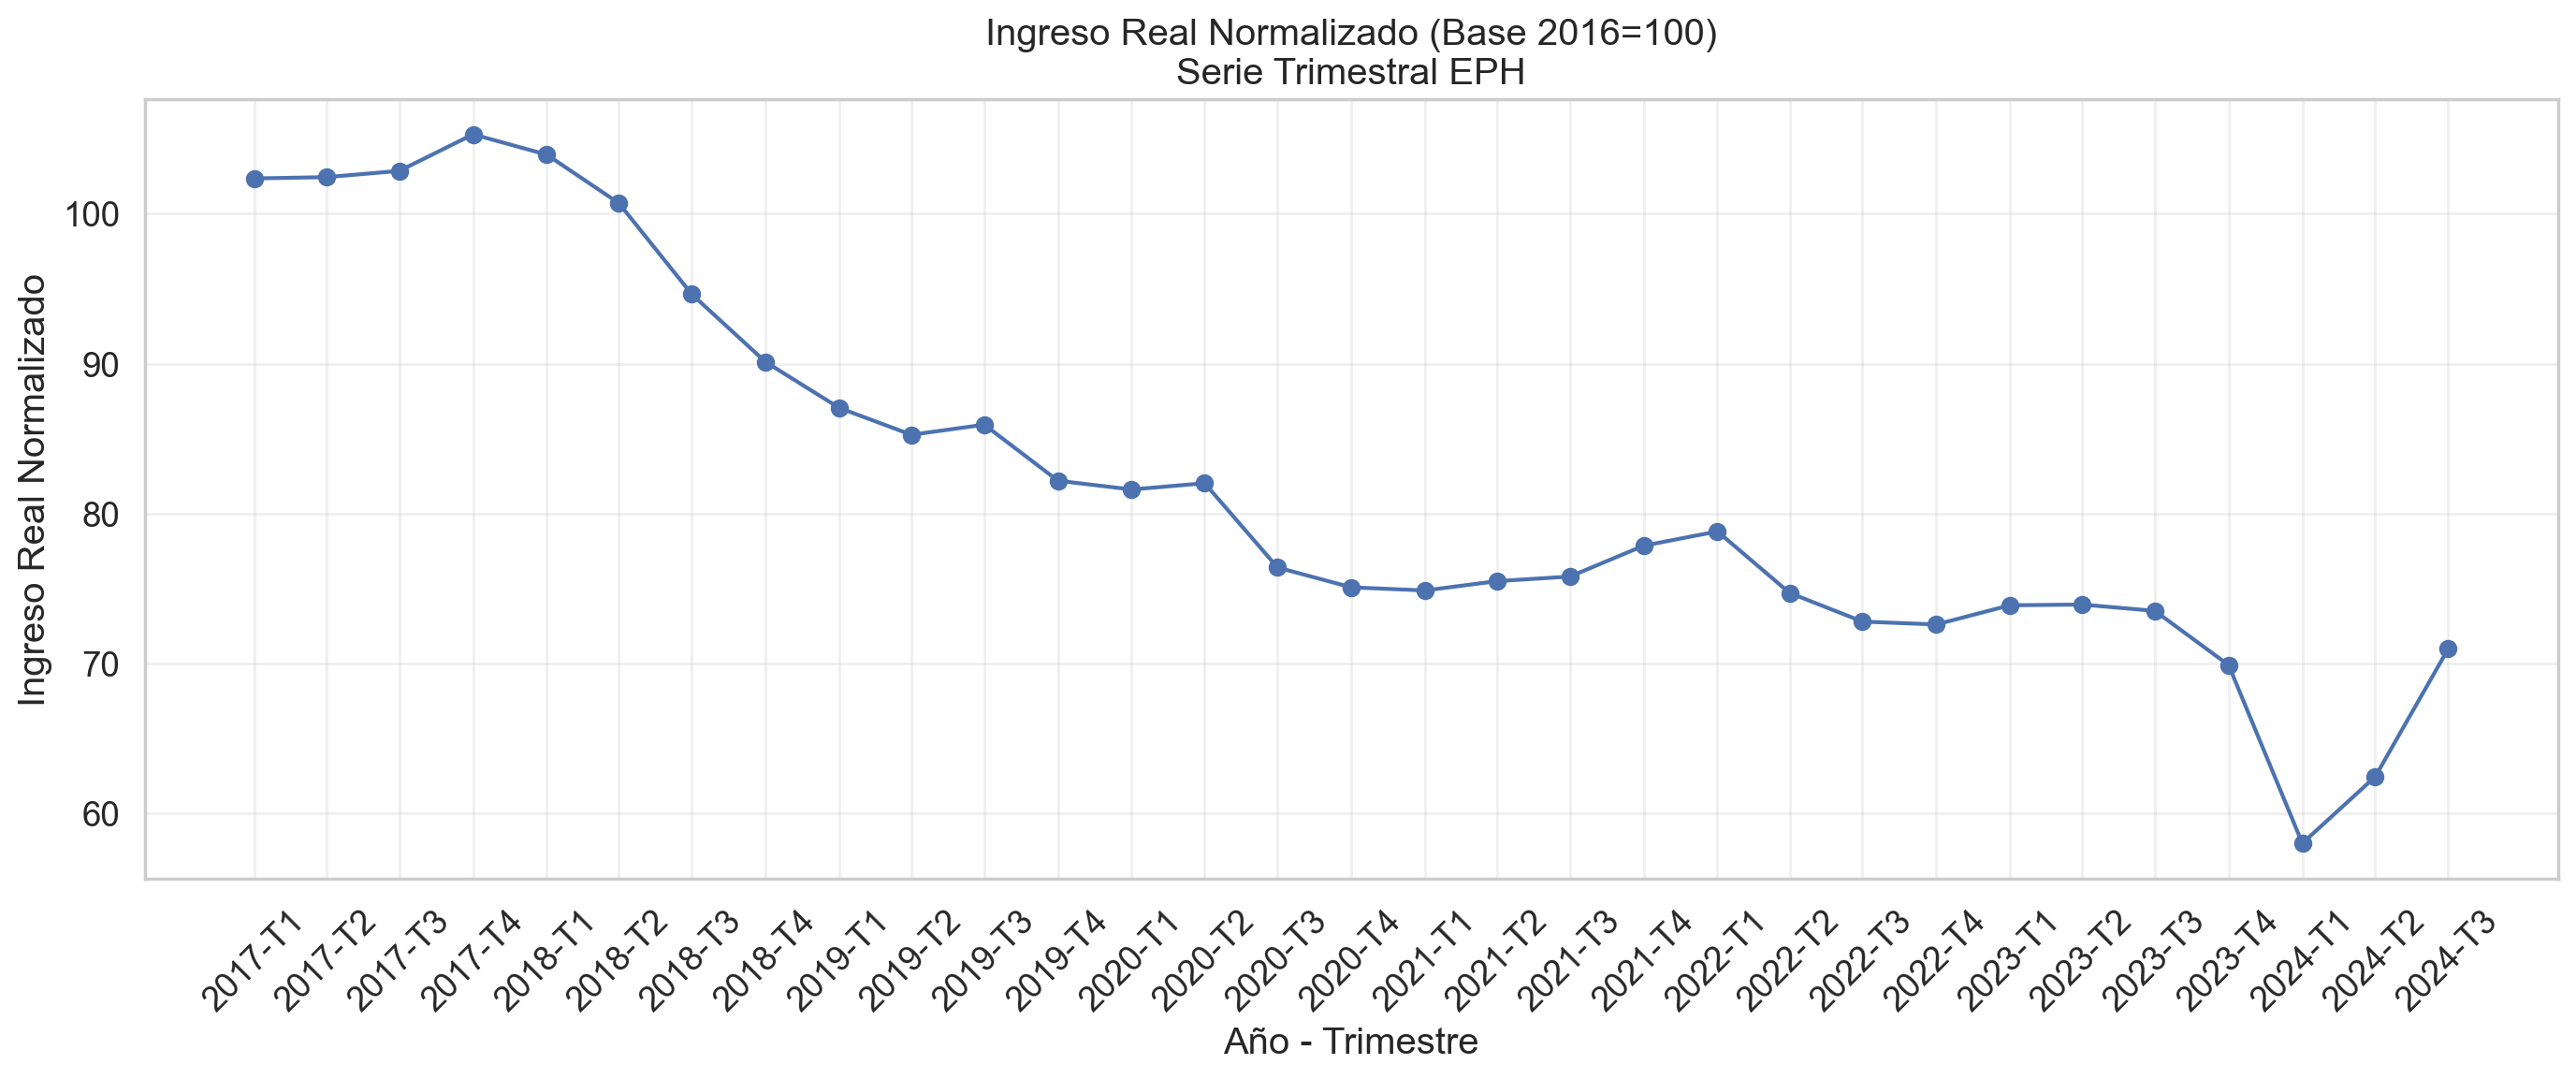

In [155]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- Agrupar ---
df_agg = df_deflactado.groupby(['ANO4','TRIMESTRE'])['Ingreso_Real'].mean().reset_index()

# --- Base 2016 ---
base_2016 = df_deflactado[df_deflactado['ANO4']==2016]['Ingreso_Real'].mean()
df_agg['Ingreso_Real_Normalizado'] = df_agg['Ingreso_Real'] / base_2016 * 100

# --- Crear fecha trimestral ---
df_agg['Fecha'] = pd.PeriodIndex(
    year=df_agg['ANO4'],
    quarter=df_agg['TRIMESTRE'],
    freq='Q'
).to_timestamp()

df_agg = df_agg.sort_values('Fecha')
df_agg = df_agg[df_agg['ANO4'] >= 2017]

# --- Graficar ---
fig, ax = plt.subplots(figsize=(14,6))

ax.plot(df_agg['Fecha'],
        df_agg['Ingreso_Real_Normalizado'],
        marker='o')

# 👉 Mostrar un tick por trimestre
ax.set_xticks(df_agg['Fecha'])

# 👉 Crear etiquetas Año-T
labels = df_agg['ANO4'].astype(str) + "-T" + df_agg['TRIMESTRE'].astype(str)
ax.set_xticklabels(labels, rotation=45)

ax.set_title('Ingreso Real Normalizado (Base 2016=100)\nSerie Trimestral EPH')
ax.set_xlabel('Año - Trimestre')
ax.set_ylabel('Ingreso Real Normalizado')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

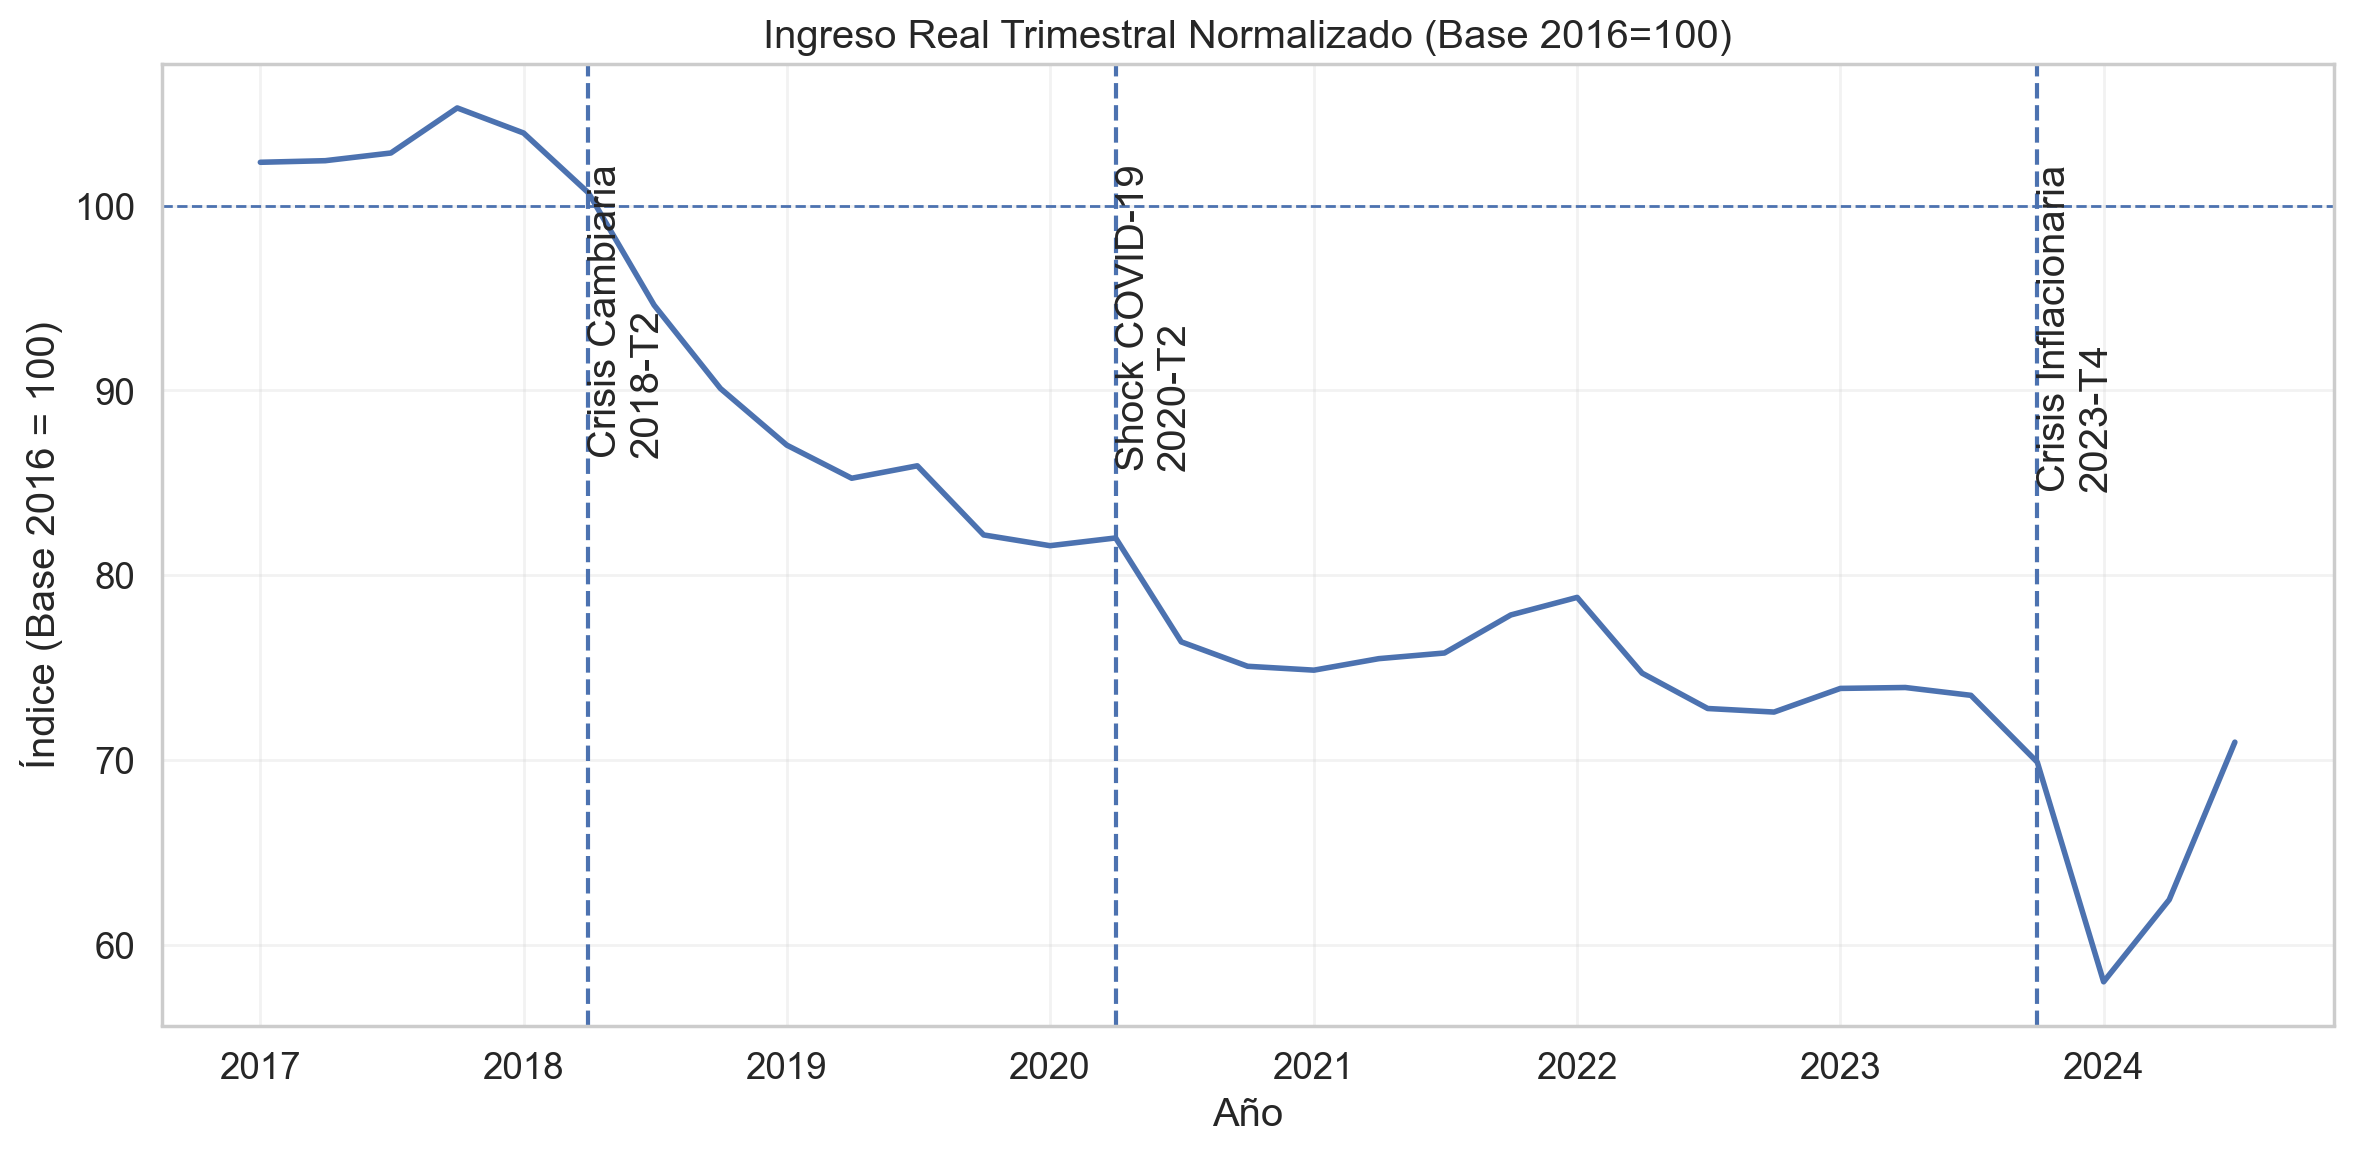

In [158]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Agrupar ---
df_agg = df_deflactado.groupby(['ANO4','TRIMESTRE'])['Ingreso_Real'].mean().reset_index()

# --- Base 2016 ---
base_2016 = df_deflactado[df_deflactado['ANO4']==2016]['Ingreso_Real'].mean()
df_agg['Ingreso_Real_Normalizado'] = df_agg['Ingreso_Real'] / base_2016 * 100

# --- Fecha trimestral ---
df_agg['Fecha'] = pd.PeriodIndex(
    year=df_agg['ANO4'],
    quarter=df_agg['TRIMESTRE'],
    freq='Q'
).to_timestamp()

df_agg = df_agg.sort_values('Fecha')
df_agg = df_agg[df_agg['ANO4'] >= 2017]

# --- Fechas de shocks ---
crisis_2018 = pd.Period('2018Q2').to_timestamp()
pandemia_2020 = pd.Period('2020Q2').to_timestamp()
crisis_2023 = pd.Period('2023Q4').to_timestamp()

# --- Gráfico ---
plt.figure(figsize=(12,6))

plt.plot(df_agg['Fecha'],
         df_agg['Ingreso_Real_Normalizado'],
         linewidth=2)

# Línea base 100
plt.axhline(100, linestyle='--', linewidth=1)

# Líneas verticales shocks
plt.axvline(crisis_2018, linestyle='--', linewidth=1.5)
plt.axvline(pandemia_2020, linestyle='--', linewidth=1.5)
plt.axvline(crisis_2023, linestyle='--', linewidth=1.5)

# Etiquetas discretas
ylim = plt.ylim()[1]

plt.text(crisis_2018, ylim*0.95, 'Crisis Cambiaria\n2018-T2',
         rotation=90, verticalalignment='top')

plt.text(pandemia_2020, ylim*0.95, 'Shock COVID-19\n2020-T2',
         rotation=90, verticalalignment='top')

plt.text(crisis_2023, ylim*0.95, 'Crisis Inflacionaria\n2023-T4',
         rotation=90, verticalalignment='top')

# Mostrar solo primer trimestre de cada año
xticks = df_agg[df_agg['TRIMESTRE']==1]['Fecha']
plt.xticks(xticks, df_agg[df_agg['TRIMESTRE']==1]['ANO4'])

plt.title('Ingreso Real Trimestral Normalizado (Base 2016=100)')
plt.xlabel('Año')
plt.ylabel('Índice (Base 2016 = 100)')
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [156]:
df_deflactado['Nivel Educativo'].value_counts(dropna=False)

Secundario completo         514134
Universitario completo      378779
Secundario incompleto       294092
Universitario incompleto    235224
Primario completo           224993
Primario incompleto          55790
Sin instrucción               5331
Name: Nivel Educativo, dtype: int64

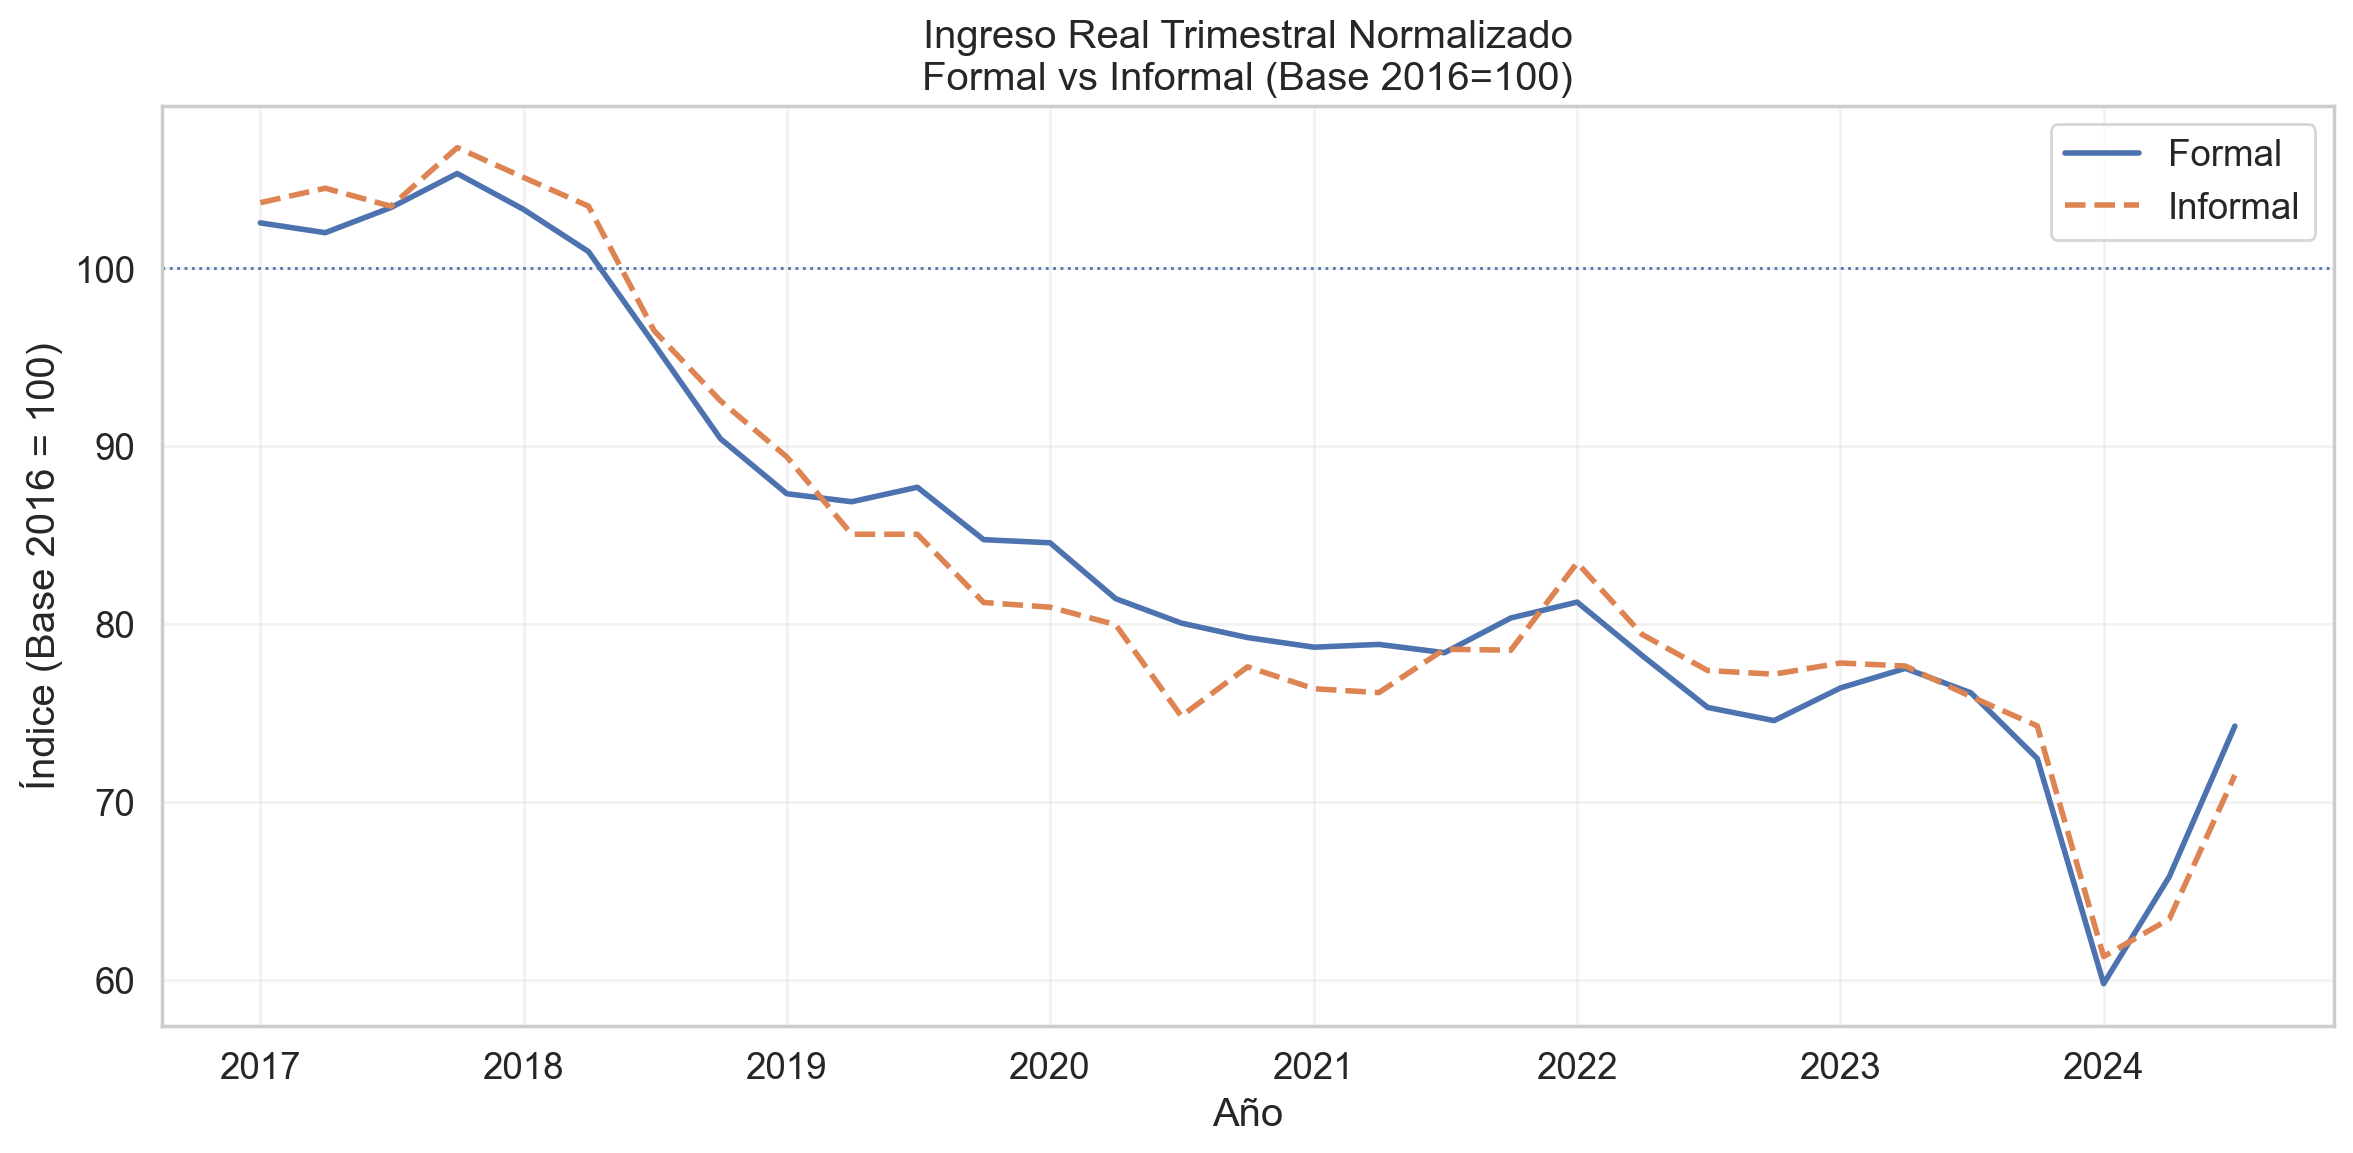

In [162]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Base 2016 por grupo ---
base_2016 = (
    df_deflactado[df_deflactado['ANO4'] == 2016]
    .groupby('Informalidad_laboral')['Ingreso_Real']
    .mean()
)

# --- Agrupar por año, trimestre y tipo ---
df_agg = (
    df_deflactado
    .groupby(['ANO4','TRIMESTRE','Informalidad_laboral'])['Ingreso_Real']
    .mean()
    .reset_index()
)

# --- Merge con base ---
df_agg = df_agg.merge(
    base_2016.rename('Base_2016'),
    on='Informalidad_laboral',
    how='left'
)

# --- Normalizar ---
df_agg['Ingreso_Normalizado'] = (
    df_agg['Ingreso_Real'] / df_agg['Base_2016'] * 100
)

# --- Crear fecha trimestral ---
df_agg['Fecha'] = pd.PeriodIndex(
    year=df_agg['ANO4'],
    quarter=df_agg['TRIMESTRE'],
    freq='Q'
).to_timestamp()

df_agg = df_agg.sort_values('Fecha')
df_agg = df_agg[df_agg['ANO4'] >= 2017]

# --- Gráfico profesional ---
plt.figure(figsize=(12,6))

for grupo in ['Formal','Informal']:
    datos = df_agg[df_agg['Informalidad_laboral'] == grupo]
    estilo = '-' if grupo == 'Formal' else '--'
    
    plt.plot(datos['Fecha'],
             datos['Ingreso_Normalizado'],
             linestyle=estilo,
             linewidth=2,
             label=grupo)

plt.axhline(100, linestyle=':', linewidth=1)

plt.title('Ingreso Real Trimestral Normalizado\nFormal vs Informal (Base 2016=100)')
plt.xlabel('Año')
plt.ylabel('Índice (Base 2016 = 100)')
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [161]:
print(df_deflactado[['ANO4','TRIMESTRE','Ingreso_Real','Informalidad_laboral']].head())

   ANO4  TRIMESTRE  Ingreso_Real Informalidad_laboral
0  2017          1     1476.3780             Informal
1  2017          1     1446.0117             Informal
2  2017          1     1412.1208             Informal
3  2017          1     9350.3937               Formal
4  2017          1     9158.0741               Formal


In [151]:
df_deflactado.columns

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel Educativo', 'Género', 'Edad', 'Nacionalidad',
       'Maximo Nivel Educativo', 'Finalizo Nivel', 'Ultimo Año Aprobado',
       'Nacionalidad', 'PONDERA', 'Categoria Ocupacional',
       'Categoria Inactividad', 'Tiempo Trabajado', 'Horas trabajadas',
       'Tipo empleador', 'Descuento jubilatorio', 'Años Educacion',
       'Experiencia Potencial', 'Experiencia Potencial Cuadrado',
       'Edad_Cuadrado', 'Ingreso Principal', 'ITF', 'Provincia',
       'Informalidad_laboral', 'Ano', 'Trimestre', 'Factor_Deflactacion',
       'Ingreso_Real'],
      dtype='object')

In [143]:
# ==========================================
# 1️⃣ Renombrar columnas para evitar errores
# ==========================================
df_deflactado.rename(columns={
    'Nivel Educativo': 'Nivel_Educativo',
    'Tipo empleador': 'Tipo_empleador',
    'Experiencia Potencial': 'Experiencia_Potencial',
    'Experiencia Potencial Cuadrado': 'Experiencia_Potencial_Cuadrado',
    'Ingreso Principal': 'Ingreso_Real',
    'Años Educacion': 'Edu'
}, inplace=True)

# ==========================================
# 2️⃣ Crear logaritmo del ingreso
# ==========================================
import numpy as np
df_deflactado['log_ingreso'] = np.log(df_deflactado['Ingreso_Real'])

# ==========================================
# 3️⃣ Especificación WLS con efectos fijos por año
# ==========================================
import statsmodels.formula.api as smf

formula = """
log_ingreso ~ 
Edu +
Experiencia_Potencial +
Experiencia_Potencial_Cuadrado +
Informalidad_laboral +
Edu:Informalidad_laboral +
C(Género) +
C(Categoria_Ocupacional) +
C(Tipo_empleador) +
C(Provincia) +
C(ANO4)
"""

modelo = smf.wls(
    formula=formula,
    data=df_deflactado,
    weights=df_deflactado["PONDERA"]
).fit(cov_type="HC1")  # errores robustos

# ==========================================
# 4️⃣ Mostrar resumen del modelo
# ==========================================
print(modelo.summary())

# ==========================================
# 5️⃣ Calcular retornos educativos
# ==========================================
# Retorno educación en formal (Informalidad_laboral=0)
beta1 = modelo.params['Edu']

# Diferencia en informalidad (interacción)
beta5 = modelo.params['Edu:Informalidad_laboral[T.Sí]']  # si tu dummy es Sí/No

retorno_formal = beta1
retorno_informal = beta1 + beta5

print(f"Retorno educación formal: {retorno_formal:.3f} (~{retorno_formal*100:.1f}%)")
print(f"Retorno educación informal: {retorno_informal:.3f} (~{retorno_informal*100:.1f}%)")

ValueError: Cannot set a DataFrame with multiple columns to the single column log_ingreso

In [68]:
# ==========================================
# 1️⃣ Renombrar columnas automáticamente
# ==========================================
df_deflactado.rename(columns={col: col.replace(" ", "_") for col in df_deflactado.columns}, inplace=True)

# ==========================================
# 2️⃣ Crear logaritmo del ingreso
# ==========================================
import numpy as np
df_deflactado['log_ingreso'] = np.log(df_deflactado['Ingreso_Real'])

# ==========================================
# 3️⃣ Fórmula del modelo Mincer extendido
# ==========================================
import statsmodels.formula.api as smf

formula = """
log_ingreso ~ 
Edu +
Experiencia_Potencial +
Experiencia_Potencial_Cuadrado +
Informalidad_laboral +
Edu:Informalidad_laboral +
C(Género) +
C(Categoria_Ocupacional) +
C(Tipo_empleador) +
C(Provincia) +
C(ANO4)
"""

# ==========================================
# 4️⃣ Estimación WLS con ponderación y errores robustos
# ==========================================
modelo = smf.wls(
    formula=formula,
    data=df_deflactado,
    weights=df_deflactado["PONDERA"]
).fit(cov_type="HC1")  # errores robustos a heterocedasticidad

# ==========================================
# 5️⃣ Mostrar resumen
# ==========================================
print(modelo.summary())

# ==========================================
# 6️⃣ Calcular retornos educativos
# ==========================================
# Detectar el nombre exacto de la dummy de informalidad
dummy_informal = [col for col in modelo.params.index if "Edu:Informalidad_laboral" in col][0]

beta1 = modelo.params['Edu']            # Retorno educación formal
beta5 = modelo.params[dummy_informal]   # Diferencia educación informal

retorno_formal = beta1
retorno_informal = beta1 + beta5

print(f"Retorno educación formal: {retorno_formal:.3f} (~{retorno_formal*100:.1f}%)")
print(f"Retorno educación informal: {retorno_informal:.3f} (~{retorno_informal*100:.1f}%)")

ValueError: Columns must be same length as key

In [69]:
print(df_deflactado.columns)
print(df_deflactado.columns.duplicated().sum())  # cuántas columnas duplicadas

Index(['ANO4', 'TRIMESTRE', 'Region', 'AGLOMERADO', 'Estado',
       'Nivel_Educativo', 'Género', 'Edad', 'Nacionalidad',
       'Maximo_Nivel_Educativo', 'Finalizo_Nivel', 'Ultimo_Año_Aprobado',
       'Nacionalidad', 'PONDERA', 'Categoria_Ocupacional',
       'Categoria_Inactividad', 'Tiempo_Trabajado', 'Horas_trabajadas',
       'Tipo_empleador', 'Descuento_jubilatorio', 'Edu',
       'Experiencia_Potencial', 'Experiencia_Potencial_Cuadrado',
       'Edad_Cuadrado', 'Ingreso_Real', 'ITF', 'Provincia',
       'Informalidad_laboral', 'Ano', 'Trimestre', 'Factor_Deflactacion',
       'Ingreso_Real', 'log_ingreso'],
      dtype='object')
2


In [70]:
# Mantener solo la primera aparición de cada columna
df_deflactado = df_deflactado.loc[:, ~df_deflactado.columns.duplicated()]

In [71]:
df_deflactado.rename(columns={col: col.replace(" ", "_") for col in df_deflactado.columns}, inplace=True)

In [76]:
df_deflactado['Nivel_Educativo'].value_counts()

Secundario completo                   514134
Secundario incompleto                 294092
Primario completo                     224993
Primario incompleto                    55790
Terciario/Universitario incompleto         0
Terciario/Universitario completo           0
Name: Nivel_Educativo, dtype: int64

# Analisis Univariado

### Variables numéricas 